In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score, confusion_matrix
from scipy.special import expit
from girth import grm_mml
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.lines as mlines
import seaborn as sns
import re
import os
import warnings


warnings.filterwarnings("ignore")
# sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
sns.set_theme(style="whitegrid", context="poster", font_scale=1.5)

def save_multiformat(base_filename, directory="../figures_S4"):
    os.makedirs(directory, exist_ok=True)
    plt.savefig(f"{directory}/{base_filename}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{directory}/{base_filename}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{directory}/{base_filename}.pdf", format='pdf', bbox_inches='tight')

In [ ]:
# ==========================================
# 0. IMPORTS
# ==========================================
import re
import warnings

import numpy as np
import pandas as pd

import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from scipy.special import expit

from sklearn.decomposition import FactorAnalysis
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score


warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


# ==========================================
# 0. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
print("=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S4.csv"

MCMC_FILES = {
    '3. DiagOU': "../new_results/results_S4_dahlou_ncp_full_diag_run1.csv",
    '4. CLOUD': "../new_results/results_S4_dahlou_ncp_full_run1.csv"
}

df = pd.read_csv(DATA_FILE)

mcmc_dfs = {}
for name, path in MCMC_FILES.items():
    try:
        mcmc_dfs[name] = pd.read_csv(path)
    except Exception as e:
        print(f"[WARNING] Could not load {path}: {e}")

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}

all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
all_covariates = meas_covariates + dyn_covariates

# Prepare aggregations
df['Total Score'] = df[all_items].sum(axis=1)

for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
df['_row_id'] = np.arange(len(df))

df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
df['Time_Gap'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# FEATURE ENGINEERING: Time interactions for dynamic covariates
for c in dyn_covariates:
    df[f'{c}_x_Time'] = df[c] * df['ALSFRS_Delta']
    df[f'{c}_x_Gap'] = df[c] * df['Time_Gap']

meas_str = " + ".join(meas_covariates)
dyn_time_str = " + ".join([f"{c}_x_Time" for c in dyn_covariates])
dyn_gap_str = " + ".join([f"{c}_x_Gap" for c in dyn_covariates])

df['Total_Z'] = (df['Total Score'] - df['Total Score'].mean()) / df['Total Score'].std()

metrics_results = []
covariate_results = []


# ==========================================
# MODEL 2 CONFIGURATION:
# MULTIDIMENSIONAL LATENT TRAIT LMM BASELINE
# ==========================================
MODEL2_NAME = '2. MLLMM'

latent_domains = list(domains.keys())
latent_cols = [f"Lambda_{dom}_it" for dom in latent_domains]

item_to_domain = {
    item: dom
    for dom, items in domains.items()
    for item in items
}


# ==========================================
# SAFE EXTRACTION HELPERS
# ==========================================
def get_z(m, term):
    try:
        v = m.tvalues[term]
        return 0.0 if pd.isna(v) else float(v)
    except Exception:
        return 0.0


def get_se(m, term):
    try:
        v = m.bse[term]
        return 0.0 if pd.isna(v) else float(v)
    except Exception:
        return 0.0


def get_est(m, term):
    try:
        v = m.params[term]
        return 0.0 if pd.isna(v) else float(v)
    except Exception:
        return 0.0


def get_model_value_any(m, terms, attr_name):
    try:
        obj = getattr(m, attr_name)
    except Exception:
        return 0.0

    for term in terms:
        try:
            v = obj[term]
            return 0.0 if pd.isna(v) else float(v)
        except Exception:
            pass

    return 0.0


def get_z_any(m, terms):
    return get_model_value_any(m, terms, "tvalues")


def get_se_any(m, terms):
    return get_model_value_any(m, terms, "bse")


def get_est_any(m, terms):
    return get_model_value_any(m, terms, "params")


def get_mdlt_terms(dom, cov_term):
    """
    Patsy/statsmodels may name categorical interaction terms in either order.
    This helper makes extraction robust.
    """
    return [
        f"C(Latent_Domain)[{dom}]:{cov_term}",
        f"C(Latent_Domain)[T.{dom}]:{cov_term}",
        f"{cov_term}:C(Latent_Domain)[{dom}]",
        f"{cov_term}:C(Latent_Domain)[T.{dom}]",
    ]


def add_metrics(model_name, level, target, actual, expected):
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)

    mask = ~np.isnan(expected) & ~np.isnan(actual)

    if not np.any(mask):
        return

    actual_m, expected_m = actual[mask], expected[mask]

    rmse = np.sqrt(mean_squared_error(actual_m, expected_m))
    mae = mean_absolute_error(actual_m, expected_m)

    if level == 'Item':
        pred_cat = np.clip(np.round(expected_m), 0, 4)
        exact = np.mean(pred_cat == actual_m) * 100

        try:
            kappa = cohen_kappa_score(actual_m, pred_cat, weights='linear')
        except Exception:
            kappa = np.nan
    else:
        exact, kappa = np.nan, np.nan

    metrics_results.append({
        'Model': model_name,
        'Level': level,
        'Target': target,
        'RMSE': rmse,
        'MAE': mae,
        'Exact_Match_%': exact,
        'Weighted_Kappa': kappa
    })


def get_irt_exp(theta, disc, diffs):
    p_ge = [expit(disc * (theta - th)) for th in diffs]
    p4 = p_ge[3]
    p3 = p_ge[2] - p_ge[3]
    p2 = p_ge[1] - p_ge[2]
    p1 = p_ge[0] - p_ge[1]
    p0 = 1.0 - p_ge[0]
    return (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)


# ==========================================
# 1. BASELINES 1-3: FIT & PREDICT
# ==========================================
print("\nFitting Baseline Models with Robust Error Catching...")


# ==========================================================
# 1A. MODEL 2 LATENT STAGE:
# MULTIDIMENSIONAL LATENT TRAIT LMM
# ==========================================================
print(" -> Fitting multidimensional latent trait LMM stage...")

# Create standardized domain scores.
for dom in latent_domains:
    zcol = f"{dom}_Z"
    sd = df[dom].std()

    if pd.isna(sd) or sd == 0:
        df[zcol] = 0.0
    else:
        df[zcol] = (df[dom] - df[dom].mean()) / sd

latent_id_cols = ['_row_id', 'subject_id', 'ALSFRS_Delta'] + [
    f"{c}_x_Time" for c in dyn_covariates
]

latent_value_cols = [f"{dom}_Z" for dom in latent_domains]

latent_long = df[latent_id_cols + latent_value_cols].melt(
    id_vars=latent_id_cols,
    value_vars=latent_value_cols,
    var_name='Latent_Domain',
    value_name='Latent_Z'
)

latent_long['Latent_Domain'] = latent_long['Latent_Domain'].str.replace(
    '_Z',
    '',
    regex=False
)

latent_long = latent_long.dropna(
    subset=['Latent_Z', 'ALSFRS_Delta'] + [f"{c}_x_Time" for c in dyn_covariates]
).copy()

# Domain-specific fixed effects:
# each domain gets its own intercept, time slope, and dynamic covariate-time effects.
mdlt_formula = (
    "Latent_Z ~ 0 + C(Latent_Domain)"
    " + C(Latent_Domain):ALSFRS_Delta"
    + " + "
    + " + ".join([f"C(Latent_Domain):{c}_x_Time" for c in dyn_covariates])
)

# Domain-specific random intercepts with an estimated covariance matrix.
# This covariance matrix is the LMM-based domain-interdependency component.
try:
    mdlt_model = smf.mixedlm(
        mdlt_formula,
        data=latent_long,
        groups=latent_long["subject_id"],
        re_formula="0 + C(Latent_Domain)"
    )

    try:
        mdlt_lmm = mdlt_model.fit(
            reml=False,
            method='lbfgs',
            maxiter=300,
            disp=False
        )
    except Exception:
        mdlt_lmm = mdlt_model.fit(
            reml=False,
            method='powell',
            maxiter=300,
            disp=False
        )

except Exception as e:
    print(f"[WARNING] MLLMM failed; falling back to OLS latent stage: {e}")
    mdlt_lmm = smf.ols(mdlt_formula, data=latent_long).fit()

# Fitted latent scores.
try:
    latent_pred = np.asarray(mdlt_lmm.fittedvalues, dtype=float)
except Exception:
    try:
        latent_pred = np.asarray(mdlt_lmm.predict(latent_long), dtype=float)
    except Exception:
        print("[WARNING] Could not get fitted values from multidim latent model; using observed domain Z scores.")
        latent_pred = latent_long['Latent_Z'].values.astype(float)

latent_long['Lambda_hat'] = latent_pred

lambda_wide = latent_long.pivot_table(
    index='_row_id',
    columns='Latent_Domain',
    values='Lambda_hat',
    aggfunc='mean'
)

for dom in latent_domains:
    lcol = f"Lambda_{dom}_it"

    if dom in lambda_wide.columns:
        df[lcol] = df['_row_id'].map(lambda_wide[dom])
    else:
        df[lcol] = np.nan

# Store latent-stage dynamic covariate effects by domain.
mdlt_dyn_z = {dom: {} for dom in latent_domains}
mdlt_dyn_se = {dom: {} for dom in latent_domains}
mdlt_dyn_est = {dom: {} for dom in latent_domains}

for dom in latent_domains:
    for c in dyn_covariates:
        terms = get_mdlt_terms(dom, f"{c}_x_Time")

        mdlt_dyn_z[dom][c] = get_z_any(mdlt_lmm, terms)
        mdlt_dyn_se[dom][c] = get_se_any(mdlt_lmm, terms)
        mdlt_dyn_est[dom][c] = get_est_any(mdlt_lmm, terms)


def get_mdlt_effective_dyn(m_ord, cov_name):
    """
    Approximate item-level indirect effect of a dynamic covariate.

    Dynamic covariates affect the domain latent trajectories.
    The ordered item model maps the latent trajectories to item categories.

    Effective item-scale effect is approximated as:

        sum_d item_loading_d * latent_dynamic_effect_d

    SE uses a simple independence delta-method approximation.
    """
    eff_est = 0.0
    eff_var = 0.0

    for dom in latent_domains:
        lcol = f"Lambda_{dom}_it"

        loading = get_est(m_ord, lcol)
        loading_se = get_se(m_ord, lcol)

        dyn_est = mdlt_dyn_est[dom][cov_name]
        dyn_se = mdlt_dyn_se[dom][cov_name]

        eff_est += loading * dyn_est
        eff_var += (loading ** 2) * (dyn_se ** 2) + (dyn_est ** 2) * (loading_se ** 2)

    eff_se = np.sqrt(eff_var) if eff_var > 0 else 0.0
    eff_z = eff_est / eff_se if eff_se != 0 else 0.0

    return eff_est, eff_se, eff_z


# ==========================================================
# 1B. ITEM-LEVEL MODELS
# ==========================================================
for item in all_items:
    df['Item_Lag'] = df.groupby('subject_id')[item].shift(1)

    req_cols = (
        [item, 'Item_Lag', 'Time_Gap', 'ALSFRS_Delta']
        + latent_cols
        + meas_covariates
        + [f"{c}_x_Time" for c in dyn_covariates]
        + [f"{c}_x_Gap" for c in dyn_covariates]
    )

    df_clean = df.dropna(subset=req_cols).copy()

    if df_clean.empty:
        continue

    df_clean['Item_Cat'] = pd.Categorical(
        df_clean[item].astype(int),
        categories=[0, 1, 2, 3, 4],
        ordered=True
    )

    # --- Model 1: LMM ---
    m1 = None

    try:
        m1 = smf.mixedlm(
            f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}",
            data=df_clean,
            groups=df_clean["subject_id"]
        ).fit(reml=False, disp=False)
    except Exception:
        try:
            m1 = smf.ols(
                f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}",
                data=df_clean
            ).fit()
        except Exception:
            pass

    if m1 is not None:
        add_metrics(
            '1. LMM',
            'Item',
            item,
            df_clean[item].values,
            np.clip(np.asarray(m1.fittedvalues, dtype=float), 0, 4)
        )

        for c in meas_covariates:
            covariate_results.append({
                'Item': item,
                'Covariate': c,
                'Model': '1. LMM',
                'Z_Score': get_z(m1, c),
                'SE': get_se(m1, c),
                'Est': get_est(m1, c)
            })

        for c in dyn_covariates:
            covariate_results.append({
                'Item': item,
                'Covariate': c,
                'Model': '1. LMM',
                'Z_Score': get_z(m1, f'{c}_x_Time'),
                'SE': get_se(m1, f'{c}_x_Time'),
                'Est': get_est(m1, f'{c}_x_Time')
            })

    # --- Model 2: Multidimensional Latent Trait LMM ---
    try:
        exog_m2 = latent_cols + meas_covariates

        m2 = OrderedModel(
            df_clean['Item_Cat'],
            df_clean[exog_m2],
            distr='logit'
        ).fit(method='bfgs', disp=False, maxiter=300)

        pred_probs = np.asarray(m2.predict(df_clean[exog_m2]), dtype=float)
        exp_item = (pred_probs * np.arange(5)).sum(axis=1)

        add_metrics(
            MODEL2_NAME,
            'Item',
            item,
            df_clean[item].values,
            exp_item
        )

        # Direct measurement covariate effects from the ordinal item model.
        for c in meas_covariates:
            covariate_results.append({
                'Item': item,
                'Covariate': c,
                'Model': MODEL2_NAME,
                'Z_Score': get_z(m2, c),
                'SE': get_se(m2, c),
                'Est': get_est(m2, c)
            })

        # Indirect dynamic effects through multidimensional latent trajectories.
        for c in dyn_covariates:
            eff_est, eff_se, eff_z = get_mdlt_effective_dyn(m2, c)

            covariate_results.append({
                'Item': item,
                'Covariate': c,
                'Model': MODEL2_NAME,
                'Z_Score': eff_z,
                'SE': eff_se,
                'Est': eff_est
            })

    except Exception:
        pass


# ==========================================================
# 1C. MACRO-LEVEL MODELS: TOTAL SCORE AND DOMAINS
# ==========================================================
for target, items in scenarios.items():
    level = 'Overall' if target == 'Total Score' else 'Domain'
    max_val = 48 if level == 'Overall' else 12

    df_agg = df.dropna(
        subset=(
            [target, 'ALSFRS_Delta']
            + latent_cols
            + meas_covariates
            + [f"{c}_x_Time" for c in dyn_covariates]
        )
    ).copy()

    if df_agg.empty:
        continue

    agg_form_1 = (
        f"Q('{target}') ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
        if ' ' in target
        else f"{target} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
    )

    # --- Model 1: LMM Macro ---
    agg1 = None

    try:
        agg1 = smf.mixedlm(
            agg_form_1,
            data=df_agg,
            groups=df_agg["subject_id"]
        ).fit(reml=False, disp=False)
    except Exception:
        try:
            agg1 = smf.ols(agg_form_1, data=df_agg).fit()
        except Exception:
            pass

    if agg1 is not None:
        add_metrics(
            '1. LMM',
            level,
            target,
            df_agg[target].values,
            np.clip(np.asarray(agg1.fittedvalues, dtype=float), 0, max_val)
        )

    # --- Model 2: Multidimensional Latent Trait LMM Macro ---
    exp_lpmm = pd.Series(0.0, index=df_agg.index)
    exog_m2_macro = latent_cols + meas_covariates
    used_any_m2_item = False

    for item in items:
        item_subset_cols = [item] + exog_m2_macro

        df_item_macro = df_agg.dropna(subset=item_subset_cols).copy()

        if df_item_macro.empty:
            continue

        df_item_macro['Item_Cat'] = pd.Categorical(
            df_item_macro[item].astype(int),
            categories=[0, 1, 2, 3, 4],
            ordered=True
        )

        try:
            m2_i = OrderedModel(
                df_item_macro['Item_Cat'],
                df_item_macro[exog_m2_macro],
                distr='logit'
            ).fit(method='bfgs', disp=False, maxiter=300)

            pred_probs = np.asarray(
                m2_i.predict(df_item_macro[exog_m2_macro]),
                dtype=float
            )

            exp_item_i = (pred_probs * np.arange(5)).sum(axis=1)

            exp_lpmm.loc[df_item_macro.index] += exp_item_i
            used_any_m2_item = True

        except Exception:
            pass

    if used_any_m2_item:
        add_metrics(
            MODEL2_NAME,
            level,
            target,
            df_agg[target].values,
            exp_lpmm.values
        )


# ==========================================
# 2. EXTRACT CLOUD MCMC METRICS & COVARIATES
# ==========================================
print("\nExtracting CLOUD (MCMC) Parameters across restricted domains...")


def ext_stan(df_m, param, shape):
    out = np.zeros(shape)
    pattern = rf"^{param}\["

    subset = df_m[df_m['Parameter'].astype(str).str.contains(pattern, regex=True)].copy()

    for _, r in subset.iterrows():
        try:
            idx_str = re.search(r'\[(.*?)\]', str(r['Parameter']))

            if not idx_str:
                continue

            idx = [int(i) - 1 for i in idx_str.group(1).split(',')]

            if len(idx) > len(shape):
                continue

            valid = True

            for j, dim_idx in enumerate(idx):
                if dim_idx >= shape[j] or dim_idx < 0:
                    valid = False

            if not valid:
                continue

            if len(idx) == 1:
                out[idx[0]] = r['Estimate']
            elif len(idx) == 2:
                out[idx[0], idx[1]] = r['Estimate']
            elif len(idx) == 3:
                out[idx[0], idx[1], idx[2]] = r['Estimate']

        except Exception:
            pass

    return out


def extract_ppp(df_m, pattern, name_mapping=None):
    """
    Safely extracts posterior predictive p-values from the MCMC summary dataframe.
    """
    subset = df_m[df_m['Parameter'].astype(str).str.contains(
        pattern,
        regex=True,
        case=False
    )].copy()

    res = {}

    for _, row in subset.iterrows():
        param = str(row['Parameter'])
        est = row['Estimate']

        idx_match = re.search(r'\[(\d+)\]', param)

        if idx_match and name_mapping:
            idx = int(idx_match.group(1)) - 1

            if idx in name_mapping:
                res[name_mapping[idx]] = est
        else:
            res[param] = est

    return res


X_m = df[['Sex_Female', 'Treatment_Active', 'Age_Base']].fillna(0).values
actual_sc = df[all_items].values

sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values

domain_idx_full = {
    0: [0, 1, 2],
    1: [3, 4, 5],
    2: [6, 7, 8],
    3: [9, 10, 11]
}

for model_name, df_mcmc in mcmc_dfs.items():
    print(f" -> Processing {model_name}...")

    is_3d = '3D' in model_name
    valid_k = 9 if is_3d else 12

    domain_idx = {
        0: [0, 1, 2],
        1: [3, 4, 5],
        2: [6, 7, 8]
    } if is_3d else domain_idx_full

    theta = ext_stan(df_mcmc, 'theta', (12, 4))
    lam = ext_stan(df_mcmc, 'lambda', (12,))
    beta = ext_stan(df_mcmc, 'beta', (12, 3))
    xi = ext_stan(df_mcmc, 'xi', (4, len(df)))
    b = ext_stan(df_mcmc, 'b', (len(sub_map), 12))

    exp_sc = np.full((len(df), 12), np.nan)

    for i in range(len(df)):
        for d, items in domain_idx.items():
            for k in items:
                eta = np.dot(X_m[i, :], beta[k]) + lam[k] * xi[d, i] + b[ID[i], k]

                p = [expit(1.0 * (eta - th)) for th in theta[k]]

                p4 = p[3]
                p3 = p[2] - p[3]
                p2 = p[1] - p[2]
                p1 = p[0] - p[1]
                p0 = 1.0 - p[0]

                exp_sc[i, k] = (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)

    for k in range(valid_k):
        add_metrics(
            model_name,
            'Item',
            all_items[k],
            actual_sc[:, k],
            exp_sc[:, k]
        )

    for d, items in domain_idx.items():
        add_metrics(
            model_name,
            'Domain',
            list(domains.keys())[d],
            actual_sc[:, items].sum(axis=1),
            exp_sc[:, items].sum(axis=1)
        )

    if not is_3d:
        add_metrics(
            model_name,
            'Overall',
            'Total Score',
            actual_sc.sum(axis=1),
            exp_sc.sum(axis=1)
        )

    cov_map_beta = {
        1: 'Sex_Female',
        2: 'Treatment_Active',
        3: 'Age_Base'
    }

    cov_map_alpha = {
        1: 'Bulbar_Onset',
        2: 'FVC_Base',
        3: 'BMI_Base'
    }

    df_beta = df_mcmc[df_mcmc['Parameter'].astype(str).str.contains(
        r'^beta\[',
        regex=True
    )].copy()

    if not df_beta.empty:
        df_beta[['Dim1', 'Cov_idx']] = df_beta['Parameter'].astype(str).str.extract(
            r'\[(\d+),(\d+)\]'
        ).astype(int)

        for _, row in df_beta.iterrows():
            c_idx = int(row['Cov_idx'])

            if c_idx not in cov_map_beta:
                continue

            k_idx = int(row['Dim1']) - 1

            if k_idx >= valid_k:
                continue

            c_name = cov_map_beta[c_idx]
            item_name = all_items[k_idx]

            est = row['Estimate']
            se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)

            covariate_results.append({
                'Item': item_name,
                'Covariate': c_name,
                'Model': model_name,
                'Z_Score': est / se if se != 0 else 0.0,
                'SE': se,
                'Est': est
            })

    df_alpha = df_mcmc[df_mcmc['Parameter'].astype(str).str.contains(
        r'^alpha_dyn\[',
        regex=True
    )].copy()

    if not df_alpha.empty:
        df_alpha[['Dim1', 'Cov_idx']] = df_alpha['Parameter'].astype(str).str.extract(
            r'\[(\d+),(\d+)\]'
        ).astype(int)

        for _, row in df_alpha.iterrows():
            c_idx = int(row['Cov_idx'])

            if c_idx not in cov_map_alpha:
                continue

            dom_idx = int(row['Dim1']) - 1

            if dom_idx not in domain_idx:
                continue

            c_name = cov_map_alpha[c_idx]

            phi_est = row['Estimate']
            phi_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)

            for k_idx in domain_idx[dom_idx]:
                item_name = all_items[k_idx]
                lam_k = lam[k_idx]

                comp_est = lam_k * phi_est
                comp_se = abs(lam_k) * phi_se

                covariate_results.append({
                    'Item': item_name,
                    'Covariate': c_name,
                    'Model': model_name,
                    'Z_Score': comp_est / comp_se if comp_se != 0 else 0.0,
                    'SE': comp_se,
                    'Est': comp_est
                })


# ==========================================
# 3. AGGREGATION & EXPORT
# ==========================================
print("\nAggregating Results...")

mod_order = [
    '1. LMM',
    MODEL2_NAME,
    '3. DiagOU',
    '4. CLOUD',
]

# Metrics
df_metrics = pd.DataFrame(metrics_results)

if df_metrics.empty:
    df_metrics = pd.DataFrame(columns=[
        'Model',
        'Level',
        'Target',
        'RMSE',
        'MAE',
        'Exact_Match_%',
        'Weighted_Kappa'
    ])
else:
    df_metrics = df_metrics.dropna(subset=['RMSE'])

df_metrics['Level'] = pd.Categorical(
    df_metrics['Level'],
    categories=['Overall', 'Domain', 'Item'],
    ordered=True
)

df_metrics.to_csv("master_predictive_metrics.csv", index=False)

# Covariates
df_covs = pd.DataFrame(covariate_results)

if df_covs.empty:
    df_covs = pd.DataFrame(columns=[
        'Item',
        'Covariate',
        'Model',
        'Z_Score',
        'SE',
        'Est'
    ])

df_covs['Item'] = pd.Categorical(
    df_covs['Item'],
    categories=list(reversed(all_items)),
    ordered=True
)

df_covs['Model'] = pd.Categorical(
    df_covs['Model'],
    categories=mod_order,
    ordered=True
)

df_covs['Z_Score'] = df_covs['Z_Score'].fillna(0.0)
df_covs.to_csv("master_covariates.csv", index=False)

df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()

target_order = [
    'Total Score',
    'Bulbar',
    'Fine_Motor',
    'Gross_Motor',
    'Respiratory'
]

df_macro['Target'] = pd.Categorical(
    df_macro['Target'],
    categories=target_order,
    ordered=True
)

df_item = df_metrics[df_metrics['Level'] == 'Item'].copy()


# ==========================================
# 5. TERMINAL OUTPUT
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)")
print("=" * 105)

piv_macro_rmse = df_macro.pivot(index='Target', columns='Model', values='RMSE')
print(
    piv_macro_rmse
    .reindex(index=target_order, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)

print("\n" + "=" * 105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)")
print("=" * 105)

piv_macro_mae = df_macro.pivot(index='Target', columns='Model', values='MAE')
print(
    piv_macro_mae
    .reindex(index=target_order, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)

print("\n" + "=" * 105)
print("TERMINAL EXPORT: ITEM-LEVEL ORDINAL AGREEMENT (EXACT MATCH % / KAPPA)")
print("=" * 105)

piv_item_exact = df_item.pivot(index='Target', columns='Model', values='Exact_Match_%')
piv_item_kappa = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')

print("--- ITEM EXACT MATCH % ---")
print(
    piv_item_exact
    .reindex(index=all_items, columns=mod_order)
    .to_string(float_format="{:.1f}".format, na_rep="-")
)

print("\n--- ITEM WEIGHTED KAPPA ---")
print(
    piv_item_kappa
    .reindex(index=all_items, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)


# ==========================================
# 6. LATENT PARAMETERS EXTRACTION (GAMMA, PHI, ALPHA, OMEGA)
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: CLOUD MODEL LATENT PARAMETERS (ALPHA, GAMMA, PHI, OMEGA)")
print("=" * 105)

if '4. CLOUD' in mcmc_dfs and not mcmc_dfs['4. CLOUD'].empty:
    df_cloud = mcmc_dfs['4. CLOUD']

    def extract_summary(df_m, param_name, is_2d=True):
        pattern = rf"^{param_name}\["

        subset = df_m[df_m['Parameter'].astype(str).str.contains(
            pattern,
            case=False,
            regex=True
        )].copy()

        if subset.empty:
            return None

        try:
            if is_2d:
                subset[['Dim1', 'Dim2']] = subset['Parameter'].astype(str).str.extract(
                    r'\[(\d+),(\d+)\]'
                ).astype(int)
            else:
                subset['Dim1'] = subset['Parameter'].astype(str).str.extract(
                    r'\[(\d+)\]'
                ).astype(int)
        except Exception:
            return None

        if 'sd' in subset.columns:
            subset['Std'] = subset['sd']
        elif 'StdDev' in subset.columns:
            subset['Std'] = subset['StdDev']
        elif '97.5%' in subset.columns and '2.5%' in subset.columns:
            subset['Std'] = (subset['97.5%'] - subset['2.5%']) / (2 * 1.96)
        else:
            subset['Std'] = 0.0

        subset['Formatted'] = subset.apply(
            lambda r: f"{r['Estimate']:.3f} ({r['Std']:.3f})",
            axis=1
        )

        if is_2d:
            return subset.pivot(index='Dim1', columns='Dim2', values='Formatted')
        else:
            # Return 1D as a row for easier reading
            return pd.DataFrame(subset.set_index('Dim1')['Formatted']).T

    alpha_vec = extract_summary(df_cloud, 'alpha_0', is_2d=False)
    gamma_mat = extract_summary(df_cloud, 'gamma', is_2d=True)
    phi_mat = extract_summary(df_cloud, 'phi', is_2d=True)
    omega_mat = extract_summary(df_cloud, 'Omega', is_2d=True)

    if phi_mat is None:
        phi_mat = extract_summary(df_cloud, 'alpha_dyn', is_2d=True)

    print("--- ALPHA (Latent Drift Intercept) : Mean (Std) ---")
    if alpha_vec is not None:
        print(alpha_vec.to_string(index=False, na_rep="-"))
    else:
        print("No alpha vector parameters found in MCMC output.")

    print("\n--- GAMMA (Latent Drift Matrix) : Mean (Std) ---")
    if gamma_mat is not None:
        print(gamma_mat.to_string(na_rep="-"))
    else:
        print("No Gamma matrix parameters found in MCMC output.")

    print("\n--- PHI (Latent Covariate Parameter Matrix) : Mean (Std) ---")
    if phi_mat is not None:
        print(phi_mat.to_string(na_rep="-"))
    else:
        print("No Phi/alpha_dyn matrix parameters found in MCMC output.")
        
    print("\n--- OMEGA (Latent Covariance/Correlation Matrix) : Mean (Std) ---")
    if omega_mat is not None:
        print(omega_mat.to_string(na_rep="-"))
    else:
        print("No Omega matrix parameters found in MCMC output.")

else:
    print("CLOUD model results not available for matrix extraction.")


# ==========================================
# 7. POSTERIOR PREDICTIVE P-VALUES
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: POSTERIOR PREDICTIVE P-VALUES (PPP) FOR CLOUD")
print("=" * 105)

if '4. CLOUD' in mcmc_dfs and not mcmc_dfs['4. CLOUD'].empty:
    df_cloud = mcmc_dfs['4. CLOUD']

    item_map = {i: all_items[i] for i in range(len(all_items))}
    domain_map = {i: list(domains.keys())[i] for i in range(len(domains))}

    item_ppp = extract_ppp(
        df_cloud,
        r'^ppp_item\[',
        name_mapping=item_map
    )

    domain_ppp = extract_ppp(
        df_cloud,
        r'^ppp_domain\[',
        name_mapping=domain_map
    )

    total_ppp_df = df_cloud[df_cloud['Parameter'].astype(str).str.contains(
        r'^ppp_total',
        regex=True,
        case=False
    )]

    total_ppp = (
        total_ppp_df['Estimate'].values[0]
        if not total_ppp_df.empty
        else None
    )

    print(
        f"{'--- ITEM-LEVEL PPP ---':<35} | "
        f"{'--- DOMAIN-LEVEL PPP ---':<35} | "
        f"--- TOTAL SCORE PPP ---"
    )

    max_len = max(len(item_ppp), len(domain_ppp), 1)

    item_list = list(item_ppp.items()) if item_ppp else []
    dom_list = list(domain_ppp.items()) if domain_ppp else []

    if not item_list and not dom_list and total_ppp is None:
        print("No PPP parameters such as 'ppp_item', 'ppp_domain', or 'ppp_total' found in the MCMC output.")
        print("Ensure these are computed in your Stan generated quantities block and tracked.")
    else:
        for i in range(max_len):
            i_str = (
                f"{item_list[i][0]}: {item_list[i][1]:.3f}"
                if i < len(item_list)
                else ""
            )

            d_str = (
                f"{dom_list[i][0]}: {dom_list[i][1]:.3f}"
                if i < len(dom_list)
                else ""
            )

            t_str = (
                f"Total Score: {total_ppp:.3f}"
                if i == 0 and total_ppp is not None
                else ""
            )

            print(f"{i_str:<35} | {d_str:<35} | {t_str}")

else:
    print("CLOUD model results not available for PPP extraction.")


print("\n=== PIPELINE 100% COMPLETE ===")

=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===

Fitting Baseline Models with Robust Error Catching...
 -> Fitting multidimensional latent trait LMM stage...

Extracting CLOUD (MCMC) Parameters across restricted domains...
 -> Processing 3. DiagOU...
 -> Processing 4. CLOUD...

Aggregating Results...

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)
Model        1. LMM  2. MLLMM  3. DiagOU  4. CLOUD
Target                                            
Total Score   2.552     2.472      1.546     1.533
Bulbar        0.841     0.865      0.711     0.764
Fine_Motor    0.982     0.975      0.522     0.527
Gross_Motor   0.971     0.981      0.924     0.972
Respiratory   0.988     0.982      0.483     0.500

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)
Model        1. LMM  2. MLLMM  3. DiagOU  4. CLOUD
Target                                            
Total Score   1.847     1.763      1.156     1.167
Bulbar        0.551     0.611      0.459    

Generating Final Publication Visuals in PNG, SVG, and PDF formats...
 -> Generated manuscript-ready 'Fig_AB_Macro_Metrics' with combined panels.


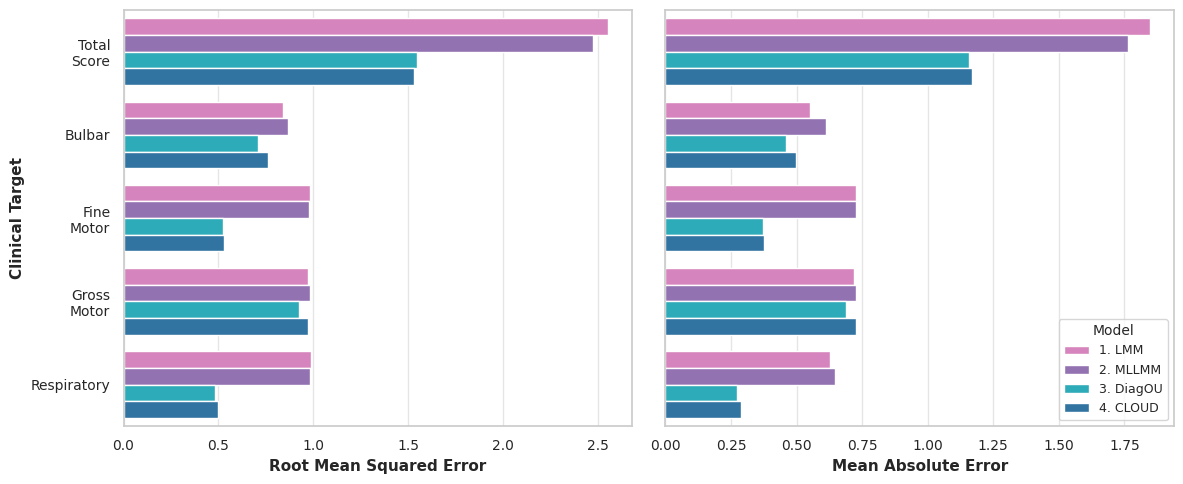

In [3]:
# ==========================================
# 4. VISUALIZATION
# ==========================================
print("Generating Final Publication Visuals in PNG, SVG, and PDF formats...")

import matplotlib.pyplot as plt
import seaborn as sns

# Optional fallback in case save_multiformat is not already defined elsewhere
if 'save_multiformat' not in globals():
    def save_multiformat(filename, dpi=600):
        plt.savefig(f"{filename}.png", dpi=dpi, bbox_inches='tight', facecolor='white')
        plt.savefig(f"{filename}.svg", bbox_inches='tight', facecolor='white')
        plt.savefig(f"{filename}.pdf", bbox_inches='tight', facecolor='white')

# Ensure the multidimensional latent baseline name exists
if 'MODEL2_NAME' not in globals():
    MODEL2_NAME = '2. MLLMM'

# White background with grid lines
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white"
    }
)

# Updated color map for the modified pipeline
model_colors = {
    '1. LMM': '#e377c2',
    MODEL2_NAME: '#9467bd',
    '3. DiagOU': '#17becf',
    '4. CLOUD': '#1f77b4',
}

# Build macro-level dataframe
df_macro_plot = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()

if df_macro_plot.empty:
    print(" -> No macro-level rows found in df_metrics. Skipping Fig_AB_Macro_Metrics.")
else:
    # Rename targets to use line breaks for tighter left margins
    rename_map = {
        'Total Score': 'Total\nScore',
        'Fine_Motor': 'Fine\nMotor',
        'Gross_Motor': 'Gross\nMotor',
        'Bulbar': 'Bulbar',
        'Respiratory': 'Respiratory'
    }

    df_macro_plot['Target_Label'] = df_macro_plot['Target'].astype(str).replace(rename_map)

    target_order = [
        'Total\nScore',
        'Bulbar',
        'Fine\nMotor',
        'Gross\nMotor',
        'Respiratory'
    ]

    df_macro_plot['Target_Label'] = pd.Categorical(
        df_macro_plot['Target_Label'],
        categories=target_order,
        ordered=True
    )

    # Use the pipeline model order when available, but only keep models that exist in df_macro_plot
    if 'mod_order' in globals():
        base_model_order = list(mod_order)
    else:
        base_model_order = [
            '1. LMM',
            MODEL2_NAME,
            '3. DiagOU',
            '4. CLOUD'
        ]

    observed_models = [
        m for m in df_macro_plot['Model'].astype(str).dropna().unique()
        if m != 'nan'
    ]

    present_model_order = [
        m for m in base_model_order
        if m in observed_models
    ]

    # Append any unexpected models that are present but not listed in mod_order
    present_model_order += [
        m for m in observed_models
        if m not in present_model_order
    ]

    # Restrict plot to models that are actually present
    df_macro_plot = df_macro_plot[
        df_macro_plot['Model'].astype(str).isin(present_model_order)
    ].copy()

    df_macro_plot['Model_Label'] = pd.Categorical(
        df_macro_plot['Model'].astype(str),
        categories=present_model_order,
        ordered=True
    )

    # Palette restricted to models present in the figure
    plot_palette = {
        m: model_colors.get(m, '#333333')
        for m in present_model_order
    }

    # Set base font sizes for publication scaling
    plt.rc('axes', titlesize=13, labelsize=11)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=9, title_fontsize=10)

    # Create a 1x2 grid sharing the Y-axis
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 5),
        sharey=True
    )

    # ==========================================
    # Panel A: Macro-Level RMSE
    # ==========================================
    sns.barplot(
        data=df_macro_plot,
        y='Target_Label',
        x='RMSE',
        hue='Model_Label',
        palette=plot_palette,
        hue_order=present_model_order,
        ax=axes[0]
    )

    # axes[0].set_title('Macro-Level RMSE', fontweight='bold')
    axes[0].set_xlabel('Root Mean Squared Error', fontweight='bold')
    axes[0].set_ylabel('Clinical Target', fontweight='bold')

    axes[0].grid(axis='x', linestyle='-', alpha=0.5)
    axes[0].set_axisbelow(True)

    legend0 = axes[0].get_legend()
    if legend0 is not None:
        legend0.remove()

    # ==========================================
    # Panel B: Macro-Level MAE
    # ==========================================
    sns.barplot(
        data=df_macro_plot,
        y='Target_Label',
        x='MAE',
        hue='Model_Label',
        palette=plot_palette,
        hue_order=present_model_order,
        ax=axes[1]
    )

    # axes[1].set_title('Macro-Level MAE', fontweight='bold')
    axes[1].set_xlabel('Mean Absolute Error', fontweight='bold')
    axes[1].set_ylabel('')

    axes[1].grid(axis='x', linestyle='-', alpha=0.5)
    axes[1].set_axisbelow(True)

    axes[1].legend(
        title='Model',
        loc='lower right',
        frameon=True
    )

    plt.tight_layout()
    save_multiformat('Fig_AB_Macro_Metrics')

    print(" -> Generated manuscript-ready 'Fig_AB_Macro_Metrics' with combined panels.")


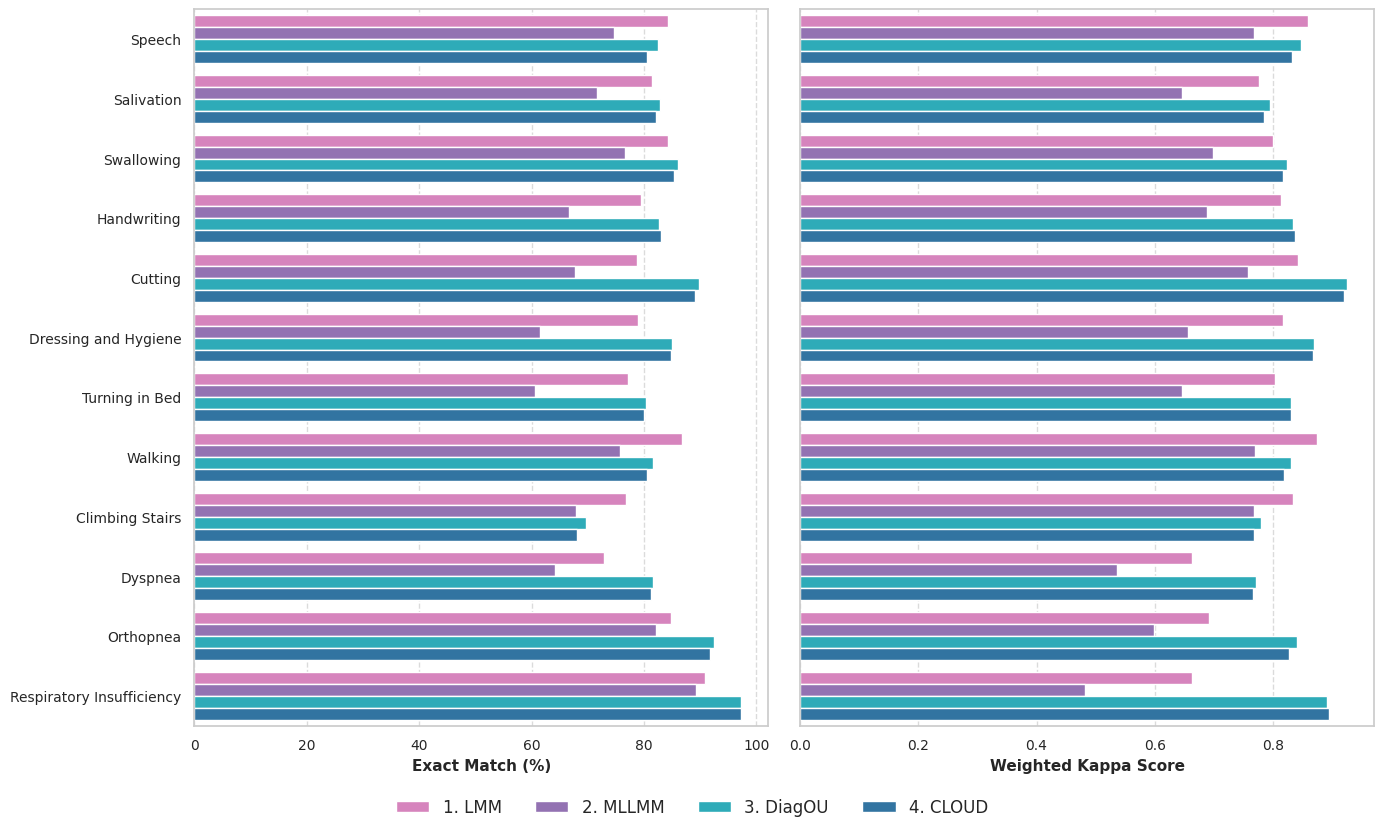

In [4]:
# ==========================================
# 3. PLOT GENERATION
# ==========================================
def plot_item_metrics(df_item, all_items, mod_order, colors):
    """
    Generates a publication-ready 1x2 paneled figure for Exact Match % and Weighted Kappa.
    """
    # Ensure strict categorical ordering to match clinical progression logic
    df_item['Target'] = pd.Categorical(df_item['Target'], categories=all_items, ordered=True)
    df_item['Model'] = pd.Categorical(df_item['Model'], categories=mod_order, ordered=True)

    # Initialize figure: 1 row, 2 columns, shared Y-axis
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 8), sharey=True)

    # --- Plot 1: Exact Match % ---
    sns.barplot(
        data=df_item,
        y='Target',
        x='Exact_Match_%',
        hue='Model',
        palette=colors,
        ax=axes[0]
    )
    # axes[0].set_title('Item-Level Exact Match (%)', fontweight='bold', pad=15)
    axes[0].set_xlabel('Exact Match (%)', fontweight='bold')
    axes[0].set_ylabel('') 
    axes[0].grid(axis='x', linestyle='--', alpha=0.7)
    axes[0].get_legend().remove() # Remove legend to consolidate later

    # --- Plot 2: Weighted Kappa ---
    sns.barplot(
        data=df_item,
        y='Target',
        x='Weighted_Kappa',
        hue='Model',
        palette=colors,
        ax=axes[1]
    )
    # axes[1].set_title('Item-Level Weighted Kappa', fontweight='bold', pad=15)
    axes[1].set_xlabel('Weighted Kappa Score', fontweight='bold')
    axes[1].set_ylabel('')
    axes[1].grid(axis='x', linestyle='--', alpha=0.7)
    
    # --- Unified Legend Configuration ---
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].get_legend().remove()
    
    # Place a single centralized legend at the bottom
    fig.legend(
        handles, labels, 
        loc='lower center', 
        ncol=len(mod_order), 
        bbox_to_anchor=(0.5, -0.05),
        frameon=False,
        fontsize=12
    )

    # Clean Y-axis labels: Replace underscores and strip out Q/R numbering prefixes
    y_labels = []
    for item in axes[0].get_yticklabels():
        # First, swap underscores for spaces (e.g., 'Q1_Speech' -> 'Q1 Speech')
        text = item.get_text().replace('_', ' ')
        # Second, use regex to remove starting 'Q' or 'R' followed by numbers and spaces
        clean_text = re.sub(r'^[QR]\s*\d+\s*', '', text)
        y_labels.append(clean_text)
        
    axes[0].set_yticklabels(y_labels)

    plt.tight_layout()
    return fig

# ==========================================
# 4. EXECUTION & EXPORT
# ==========================================
# Assuming df_item, all_items, and mod_order are loaded from your pipeline
if 'df_item' in locals() and not df_item.empty:
    fig = plot_item_metrics(df_item, all_items, mod_order, model_colors)
    
    # Execute the requested multiformat save
    save_multiformat("Fig_C_Item_Metrics")
    
    plt.show()
else:
    print("[ERROR] df_item is empty or missing. Run the ablation pipeline first.")


Generating Empirical Intuition Plots (Aggregated State vs. Velocity)...


Generated 'Fig_J_Empirical_Interaction_Velocity.png' successfully.


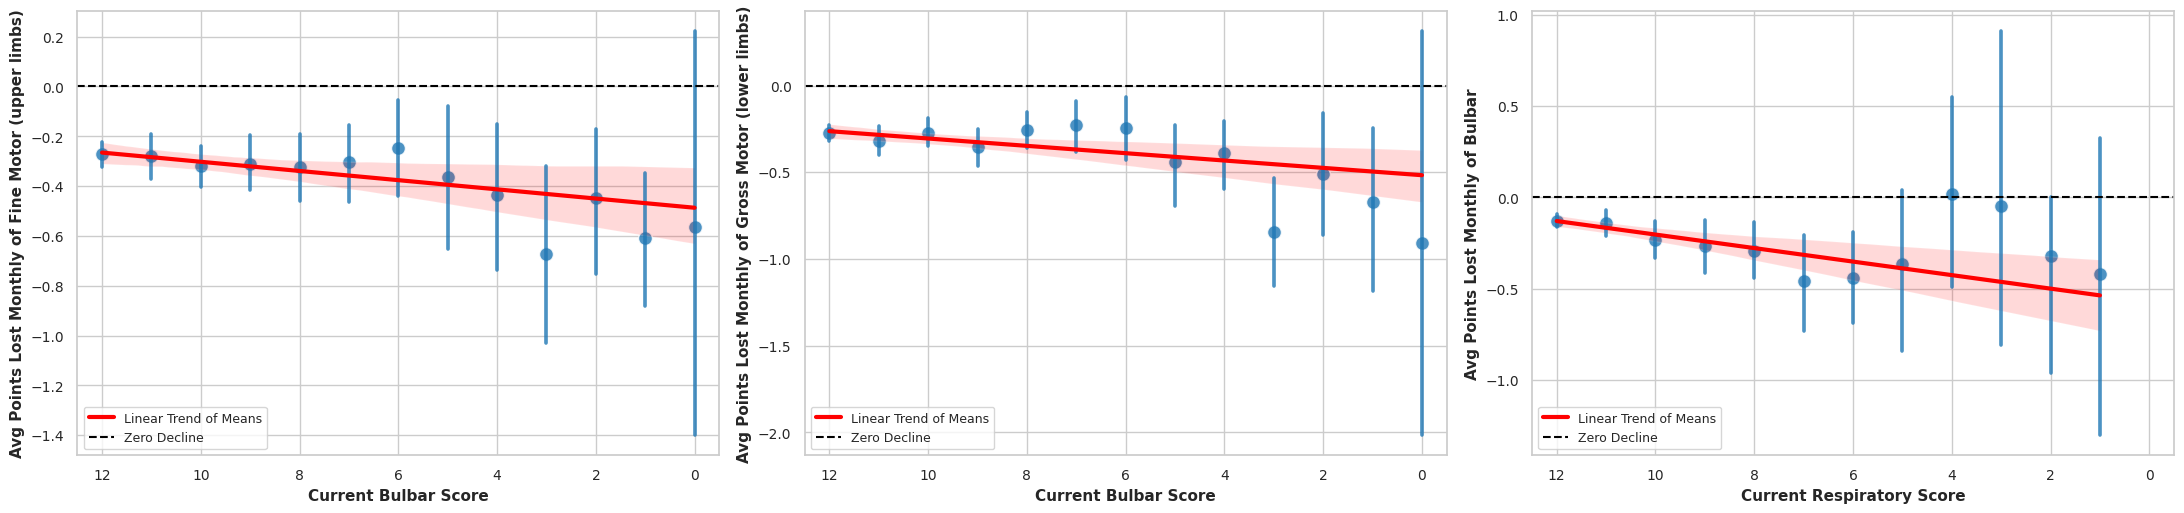

In [5]:
# ==========================================
# 7. EMPIRICAL INTUITION: STATE VS. VELOCITY (V3 - AGGREGATED MEANS)
# ==========================================
print("\nGenerating Empirical Intuition Plots (Aggregated State vs. Velocity)...")

# 1. Map data columns to standard anatomical domain names
domain_map = {
    'Bulbar': 'Bulbar',
    'Fine_Motor': 'Fine Motor (upper limbs)',  # More descriptive labeling
    'Gross_Motor': 'Gross Motor (lower limbs)',  # More descriptive labeling
    'Respiratory': 'Respiratory'  # Fixed labeling
}

df_emp = df.copy()

# Sort by subject and time to ensure sequential differences are correct
df_emp = df_emp.sort_values(by=['subject_id', 'ALSFRS_Delta'])

# Calculate the time to the NEXT visit in days
df_emp['Time_Next'] = df_emp.groupby('subject_id')['ALSFRS_Delta'].shift(-1)
df_emp['Time_Gap_Days'] = df_emp['Time_Next'] - df_emp['ALSFRS_Delta']

# Calculate forward velocities: Points lost per month (30.4 days)
for col, anat_name in domain_map.items():
    df_emp[f'{col}_Next'] = df_emp.groupby('subject_id')[col].shift(-1)
    df_emp[f'{col}_Velocity'] = ((df_emp[f'{col}_Next'] - df_emp[col]) / df_emp['Time_Gap_Days']) * 30.4

# Filter out extreme outliers (e.g., visits closer than 2 weeks or further than 1 year)
df_vel = df_emp.dropna(subset=['Time_Gap_Days']).copy()
df_vel = df_vel[(df_vel['Time_Gap_Days'] >= 14) & (df_vel['Time_Gap_Days'] <= 365)] 

# 2. Plotting the Empirical Interactions
fig_int, axes_int = plt.subplots(1, 3, figsize=(22, 6))
# fig_int.suptitle("Empirical Proof of Interaction: State vs. Expected Clinical Decline Rate", fontweight='bold', fontsize=18)

# Interaction Pairs (Checking if one domain drives the decline of another)
pairs_to_plot = [
    ('Bulbar', 'Fine_Motor'),      # Does Bulbar state affect Cervical decline?
    ('Bulbar', 'Gross_Motor'),     # Does Bulbar state affect Lumbar decline?
    ('Respiratory', 'Bulbar')      # Does Respiratory state affect Bulbar decline?
]

for i, (driver_col, target_col) in enumerate(pairs_to_plot):
    ax = axes_int[i]
    
    x_data = df_vel[driver_col]
    y_data = df_vel[f'{target_col}_Velocity']
    
    # THE FIX: Group by the integer score (0-12) and plot the mean velocity.
    # This cuts through the "zero-change" noise to reveal the true underlying slope.
    sns.regplot(
        x=x_data, y=y_data, ax=ax, 
        x_estimator=np.mean, 
        color='#1f77b4', 
        scatter_kws={'s': 100, 'alpha': 0.8, 'edgecolor': 'white'},
        line_kws={'color': 'red', 'linewidth': 3, 'label': 'Linear Trend of Means'}
    )
    
    # Baseline for zero velocity
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Decline')
    
    # Retrieve correct anatomical names for labels
    driver_name = domain_map[driver_col]
    target_name = domain_map[target_col]
    
    # Formatting (12 = Normal, 0 = Severe)
    ax.set_xlim(12.5, -0.5) 
    # ax.set_title(f"Effect of {driver_name} on\n{target_name} Decline", fontweight='bold', fontsize=14)
    ax.set_xlabel(f"Current {driver_name} Score", fontweight='bold')
    
    ax.set_ylabel(f"Avg Points Lost Monthly of {target_name}", fontweight='bold')
    
    ax.legend(loc='lower left')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
save_multiformat("Fig_J_Empirical_Interaction_Velocity")
print("Generated 'Fig_J_Empirical_Interaction_Velocity.png' successfully.")


Performing Posterior Predictive Checks (PPCs)...
Generated 'Fig_K_PPC_Distribution.png' successfully.


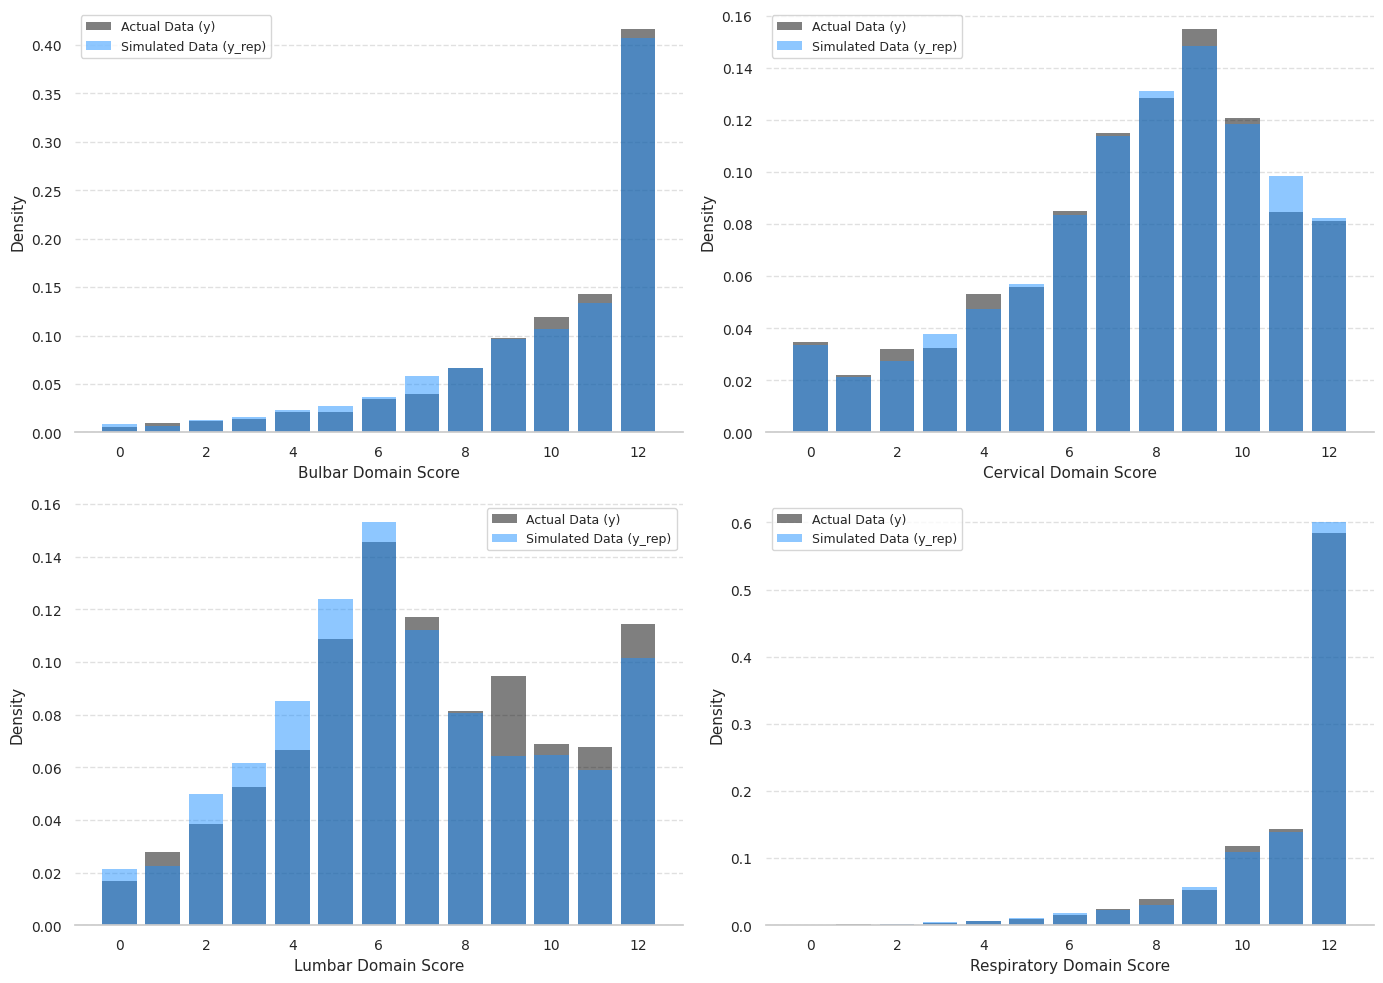

In [6]:
# ==========================================
# 8. POSTERIOR PREDICTIVE CHECKS (PPC) IN PYTHON
# ==========================================
print("\nPerforming Posterior Predictive Checks (PPCs)...")

# We will simulate data using the "Full" model (4a) as an example
model_name = '4. CLOUD' 
df_mcmc = mcmc_dfs[model_name]

# Extract parameters (reusing the safe extraction function from Section 2)
# Note: In a rigorous PPC you sample from the full posterior chain, 
# but simulating from the posterior means (which we have here) provides an excellent proxy.
theta = ext_stan(df_mcmc, 'theta', (12, 4))
lam   = ext_stan(df_mcmc, 'lambda', (12,))
beta  = ext_stan(df_mcmc, 'beta', (12, 3))
xi    = ext_stan(df_mcmc, 'xi', (4, len(df)))
b     = ext_stan(df_mcmc, 'b', (len(sub_map), 12))

# Matrix to hold our simulated categorical data
sim_sc = np.zeros((len(df), 12))

# 1. Simulate the Data
for i in range(len(df)):
    for d, items in domain_idx_full.items():
        for k in items:
            # Linear predictor
            eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
            
            # Cumulative probabilities
            p = [expit(1.0 * (eta - th)) for th in theta[k]]
            
            # Discrete category probabilities (must sum to 1)
            p_cat = [1.0-p[0], p[0]-p[1], p[1]-p[2], p[2]-p[3], p[3]]
            
            # Ensure no negative rounding errors and normalize
            p_cat = np.clip(p_cat, 0, 1)
            p_cat = p_cat / np.sum(p_cat)
            
            # Draw a random discrete score (0, 1, 2, 3, or 4) based on those probabilities
            sim_sc[i,k] = np.random.choice([0, 1, 2, 3, 4], p=p_cat)

# 2. Generate PPC Plot (Real vs Simulated Distributions)
# 2x2 layout and adjusted figsize for a square-ish proportion
fig_ppc, axes_ppc = plt.subplots(2, 2, figsize=(14, 10))

# Flatten the 2x2 array of axes into a 1D array so we can easily index it with 'd' (0, 1, 2, 3)
axes_flat = axes_ppc.flatten()

# Map domains back to standard names
domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']

for d, items in domain_idx_full.items():
    ax = axes_flat[d]
    
    # Sum the real items for this domain
    real_domain_scores = actual_sc[:, items].sum(axis=1)
    
    # Sum the simulated items for this domain
    sim_domain_scores = sim_sc[:, items].sum(axis=1)
    
    # Plot overlapping distributions
    # Added shrink=0.8 to create gaps between the discrete bars
    sns.histplot(real_domain_scores, bins=13, discrete=True, color='black', alpha=0.5, label='Actual Data (y)', stat='density', ax=ax, linewidth=0, shrink=0.8)
    sns.histplot(sim_domain_scores, bins=13, discrete=True, color='dodgerblue', alpha=0.5, label='Simulated Data (y_rep)', stat='density', ax=ax, linewidth=0, shrink=0.8)
    
    ax.set_xlabel(f"{domain_labels[d]} Domain Score")
    ax.set_ylabel("Density")
    
    # Remove vertical spines (the bounding box lines) since they aren't needed
    sns.despine(ax=ax, top=True, right=True, left=True)
    
    # Optionally remove the vertical grid lines if your default style has them enabled
    ax.grid(axis='y', linestyle='--', alpha=0.6) # Keep horizontal guide lines
    ax.grid(axis='x', visible=False)            # Remove vertical guide lines
    
    ax.legend()

plt.tight_layout()
save_multiformat("Fig_K_PPC_Distribution")
print("Generated 'Fig_K_PPC_Distribution.png' successfully.")

Generated 'Fig_R_Population_Validation_Heatmap_2x2.png' successfully.


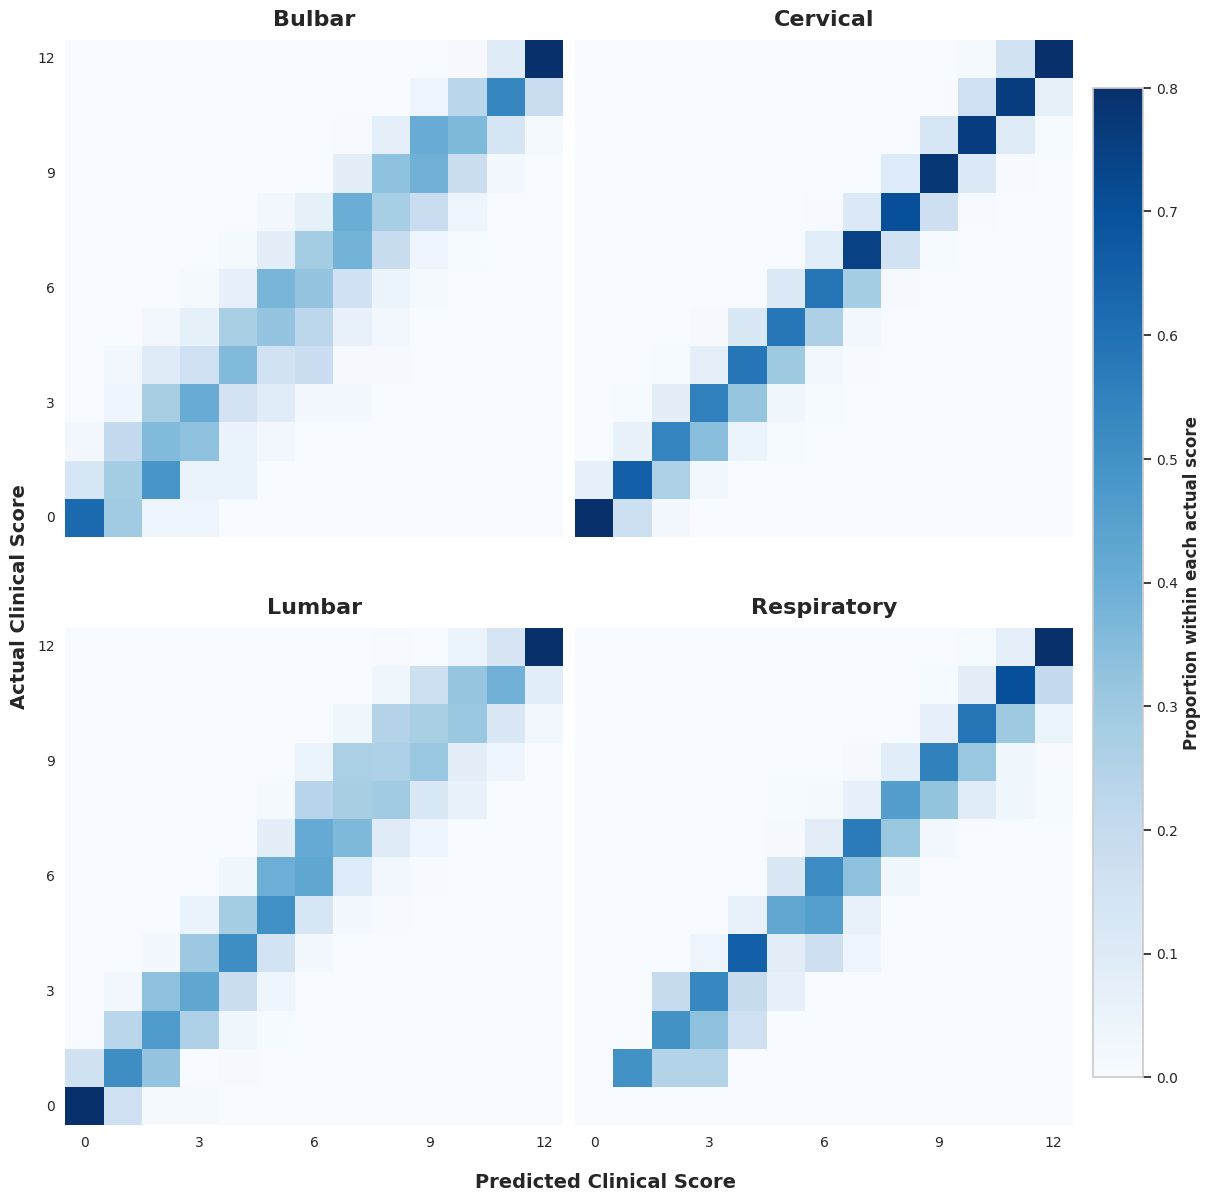

In [7]:
# Ensure the population indices are defined
visit_counts = df['subject_id'].value_counts()
long_term_patients = visit_counts[visit_counts >= 5].index
pop_pats = long_term_patients

# Transitioned to a 2x2 layout for better aspect ratio scaling
fig_fit, axes_fit = plt.subplots(
    2, 2, 
    figsize=(12, 12),   # Adjusted for a balanced 2x2 layout
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axes_flat = axes_fit.flatten()
domain_list = list(domain_idx_full.keys())

vmin, vmax = 0, 0.8
cmap = "Blues"

for idx, d in enumerate(domain_list):
    ax = axes_flat[idx]
    items = domain_idx_full[d]
    dom_name = domain_labels[d]

    all_actuals = []
    all_preds = []

    for pat_id in pop_pats:
        pat_mask = df['subject_id'] == pat_id
        all_actuals.extend(np.round(actual_sc[pat_mask][:, items].sum(axis=1)))
        all_preds.extend(np.round(exp_sc[pat_mask][:, items].sum(axis=1)))
    
    cm = confusion_matrix(all_actuals, all_preds, labels=range(13))
    cm_norm = cm.astype(float) / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

    sns.heatmap(
        cm_norm,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        # Set to 3 to plot every 3rd label (0, 3, 6, 9, 12)
        xticklabels=3, 
        yticklabels=3,
        square=True
    )

    # Ensure tick marks point outward to clearly indicate which bin the number refers to
    ax.tick_params(axis='both', which='major', length=4, width=1, direction='out')

    ax.set_title(dom_name, fontweight='bold', fontsize=16, pad=10)

    # ... rest of your layout logic ...
    
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Updated tick logic for a 2x2 grid
    # Show x tick labels only on the bottom row (indices 2 and 3)
    if idx >= 2:
        ax.tick_params(axis='x', labelbottom=True, labelrotation=0)
    else:
        ax.tick_params(axis='x', labelbottom=False)

    # Show y tick labels only on the leftmost column (indices 0 and 2)
    if idx % 2 == 0:
        ax.tick_params(axis='y', labelleft=True, labelrotation=0)
    else:
        ax.tick_params(axis='y', labelleft=False)

    ax.invert_yaxis()

# Shared figure-level axis labels
fig_fit.supxlabel(
    "Predicted Clinical Score",
    fontweight='bold',
    fontsize=14
)

fig_fit.supylabel(
    "Actual Clinical Score",
    fontweight='bold',
    fontsize=14
)

# One shared colorbar for all panels
norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# Pass the flattened axes list to span the colorbar properly across the 2x2 grid
cbar = fig_fit.colorbar(
    sm,
    ax=axes_fit.ravel().tolist(),
    shrink=0.85,
    pad=0.02
)
cbar.set_label(
    "Proportion within each actual score",
    fontweight='bold',
    fontsize=12
)

save_multiformat("Fig_R_Population_Validation_Heatmap_2x2")
print("Generated 'Fig_R_Population_Validation_Heatmap_2x2.png' successfully.")


Generating High-Density Faceted Predictive Fits...
Generated 'Fig_R_HighDensity_Personalized_Fits_Faceted.png' successfully.


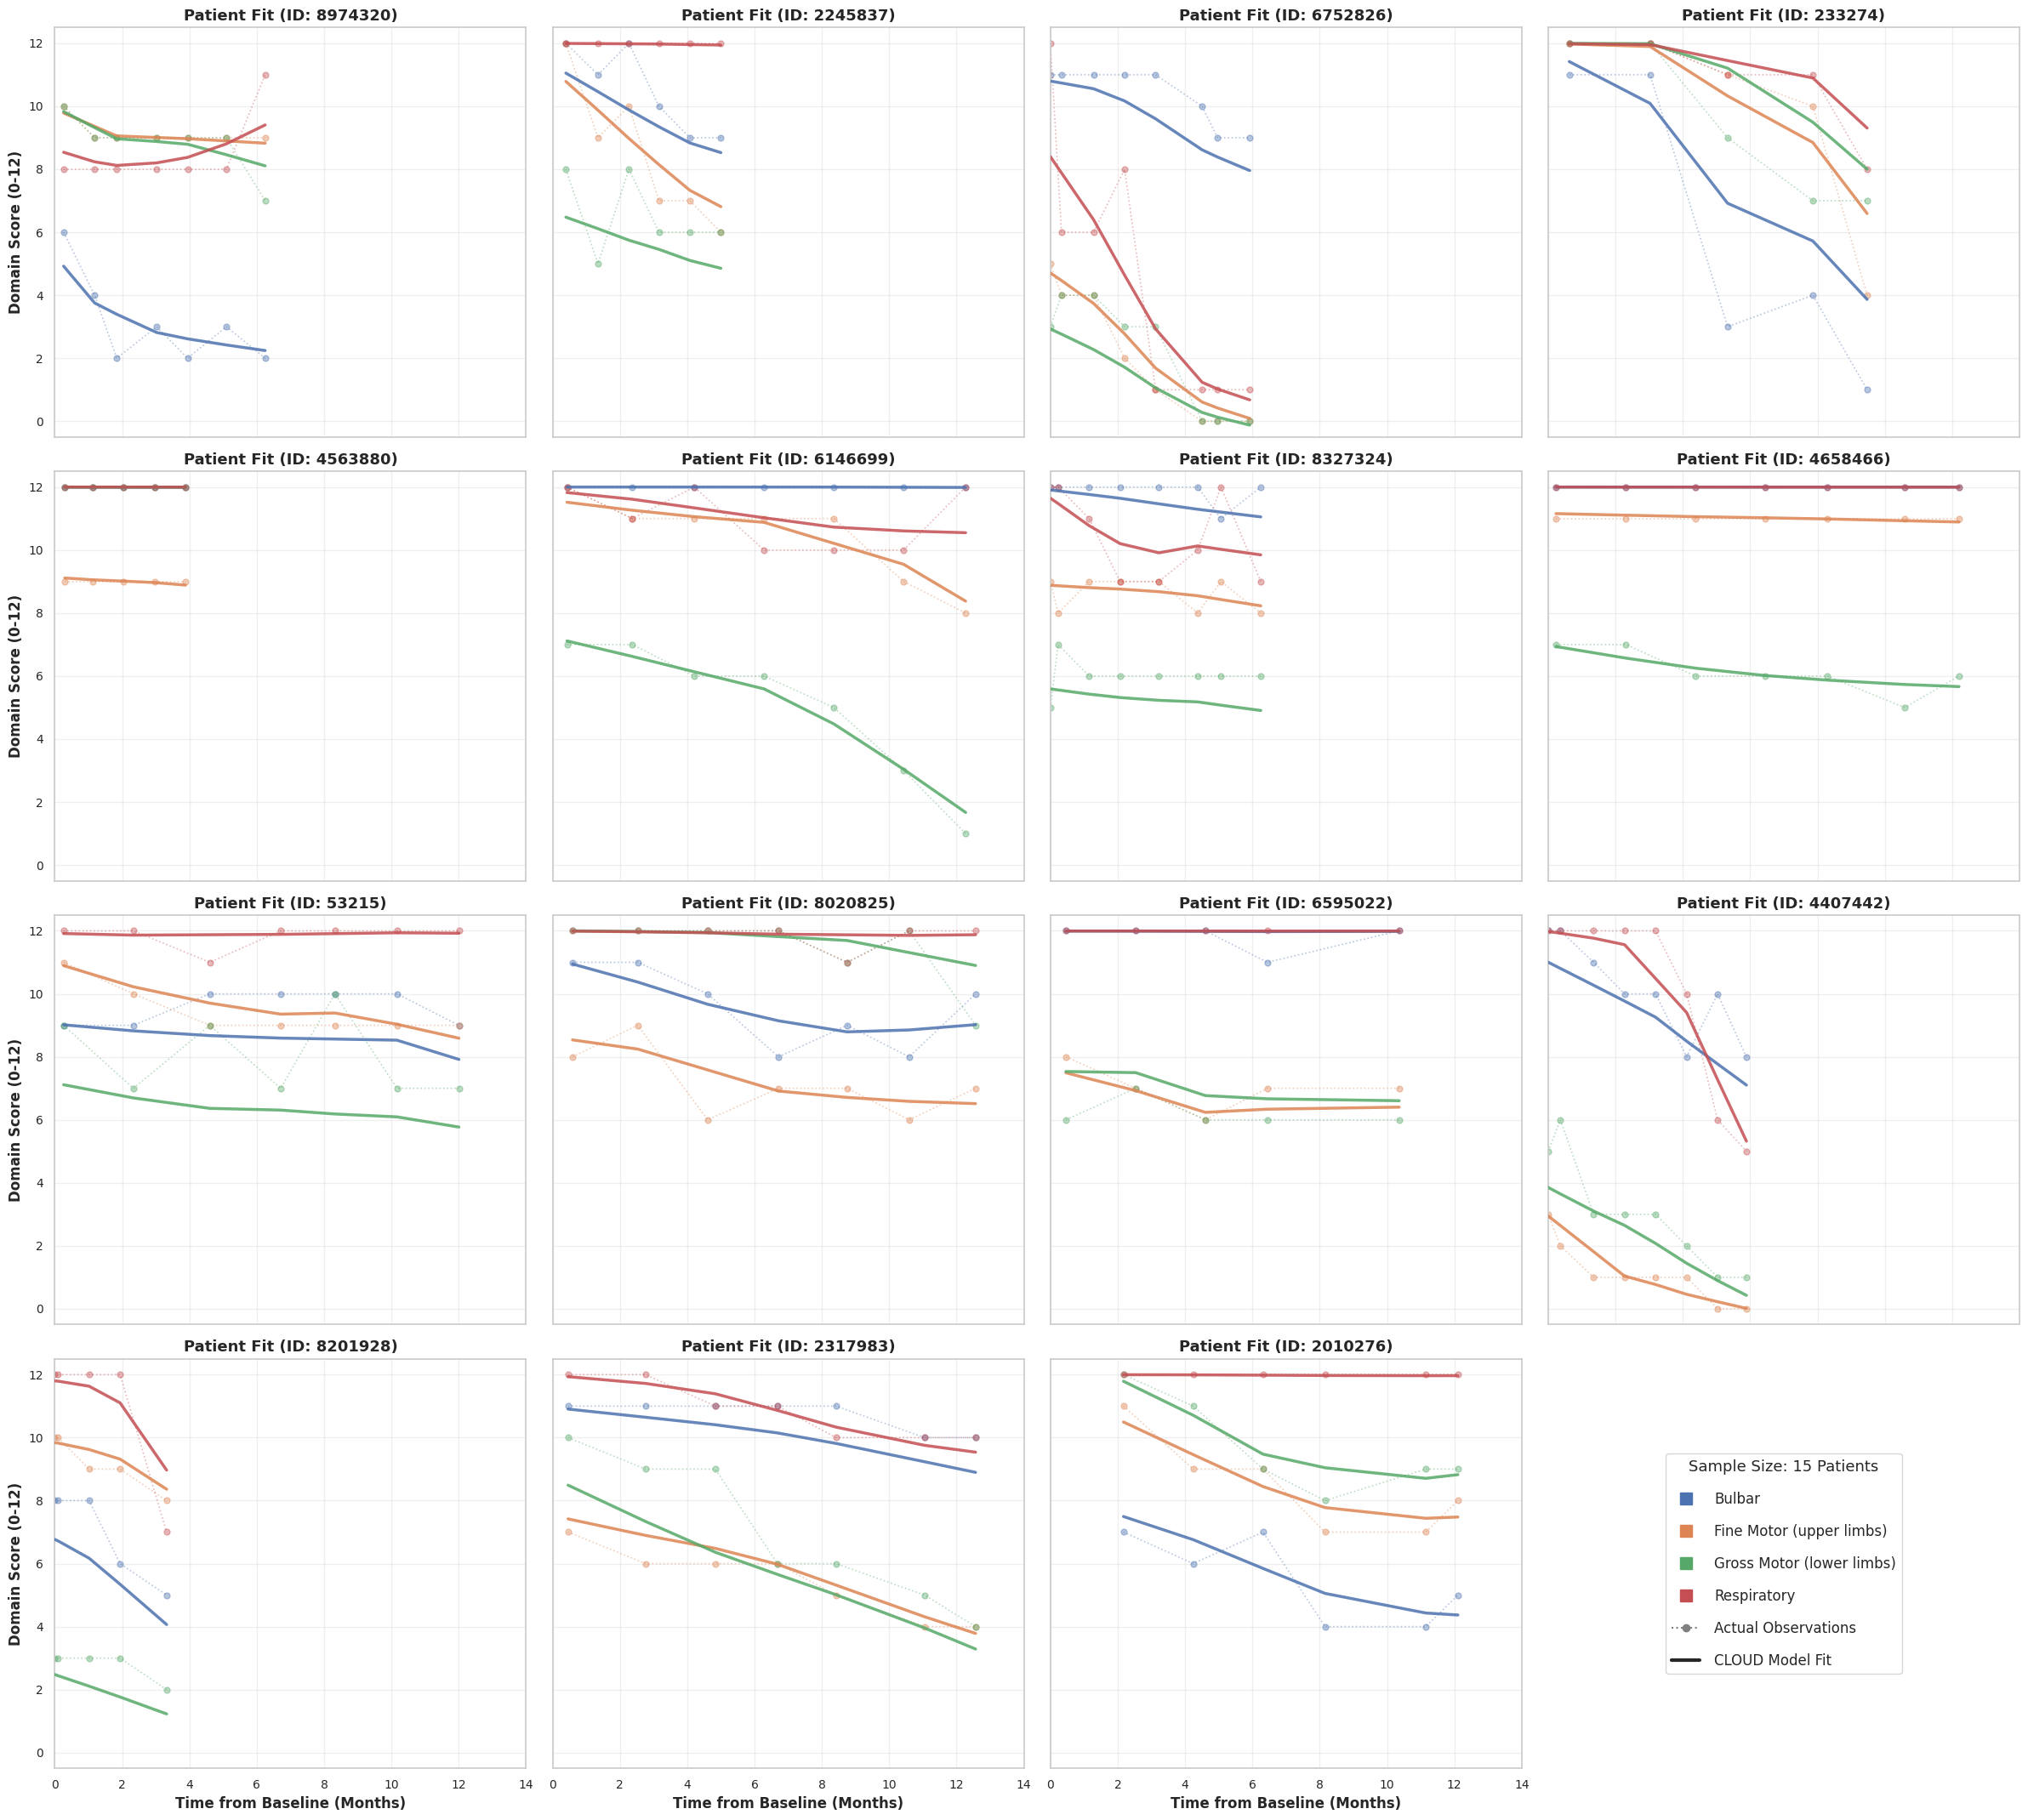

In [8]:
# ==========================================
# 13. FACETED INDIVIDUAL PREDICTIVE FIT (Small Multiples)
# ==========================================

print("\nGenerating High-Density Faceted Predictive Fits...")

# 1. Find patients with a rich longitudinal history (>= 5 visits)
visit_counts = df['subject_id'].value_counts()
long_term_patients = visit_counts[visit_counts >= 5].index

# --- PLOT CONFIGURATION ---
NUM_PATS = 15  
np.random.seed(42)
sample_pats = np.random.choice(long_term_patients, size=NUM_PATS, replace=False)

# Setup Figure (4x4 Grid - 16 Panels, with the last panel for a legend)
rows = 4
cols = 4
fig_ind, axes_ind = plt.subplots(rows, cols, figsize=(24, 22), sharex=True, sharey=True)

# fig_ind.suptitle("Faceted Individual Patient Fit (CLOUD Model)", fontweight='bold', fontsize=20, y=0.98)

domain_labels = ['Bulbar', 'Fine Motor (upper limbs)', 'Gross Motor (lower limbs)', 'Respiratory']

# Use a standard 4-color palette for the four domains
domain_colors = sns.color_palette("deep", 4)

for pat_idx, pat_id in enumerate(sample_pats):
    # Determine subplot position (r, c)
    r = pat_idx // cols
    c = pat_idx % cols
    ax = axes_ind[r, c]
    
    # Patient data extraction
    pat_mask = (df['subject_id'] == pat_id)
    pat_time = df.loc[pat_mask, 'ALSFRS_Delta'].values / 30.4
    
    # --- SUBPLOT TITLE ---
    # Convert pat_id to string to safely slice it, avoiding the scalar IndexError
    ax.set_title(f"Patient Fit (ID: {str(pat_id)[:8]})", fontweight='bold')
    
    # Iterate across the 4 Domains to plot Actual Observations and Model Fits
    for d, items in domain_idx_full.items():
        c_dom = domain_colors[d]
        dom_name = domain_labels[d]
        
        y_actual = actual_sc[pat_mask][:, items].sum(axis=1)
        y_pred = exp_sc[pat_mask][:, items].sum(axis=1)
        
        # 1. Plot Actual Data: Dots with faint, thin dotted connecting lines
        ax.plot(pat_time, y_actual, marker='o', markersize=5, color=c_dom, 
                linestyle=':', linewidth=1.2, alpha=0.4, label='_nolegend_')
        
        # 2. Plot CLOUD Prediction: Thick, smooth solid lines
        sns.regplot(
            x=pat_time, 
            y=y_pred, 
            scatter=False, 
            lowess=True, 
            color=c_dom, 
            line_kws={'linewidth': 2.5, 'alpha': 0.85, 'label': '_nolegend_', 'zorder': 3}, 
            ax=ax
        )
    
    # --- FORMATTING (Individual Small Multiple) ---
    ax.set_xlim(0, 14) 
    ax.set_ylim(-0.5, 12.5)
    
    # # Invert the common Y-axis to match typical clinical presentation (0 at the top)
    # ax.invert_yaxis()
    
    ax.grid(True, linestyle='-', alpha=0.3)
    
    # Remove labels from non-boundary panels (FacetGrid logic)
    if r < rows - 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Time from Baseline (Months)", fontweight='bold', fontsize=12)
        
    if c > 0:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Domain Score (0-12)", fontweight='bold', fontsize=12)
        
# --- CUSTOM LEGEND (Only on the last, 16th panel) ---
# Hide the boundary spines and grid for the dedicated legend subplot
axes_ind[3, 3].axis('off')
legend_ax = axes_ind[3, 3]

# Create proxy artists to explain the visual elements
domain_handles = [
    mlines.Line2D([], [], color=domain_colors[i], marker='s', markersize=10, linestyle='', label=domain_labels[i])
    for i in range(4)
]
actual_proxy = mlines.Line2D([], [], color='gray', marker='o', linestyle=':', 
                            linewidth=1.5, markersize=6, label='Actual Observations')
pred_proxy = mlines.Line2D([], [], color='black', linestyle='-', 
                          linewidth=3, alpha=0.85, label='CLOUD Model Fit')

# Build the legend within the 16th panel
legend_ax.legend(handles=domain_handles + [actual_proxy, pred_proxy], loc='center', 
                  fontsize=12, frameon=True, handletextpad=1.0, labelspacing=1.2,
                  title=f"Sample Size: {NUM_PATS} Patients", title_fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.98])
save_multiformat("Fig_R_HighDensity_Personalized_Fits_Faceted")
print("Generated 'Fig_R_HighDensity_Personalized_Fits_Faceted.png' successfully.")


Generating Empirical Motivation Plots (Independent Y-Axes)...


Generated 'Fig_M_Empirical_Domain_Covariates_IndepY' successfully.


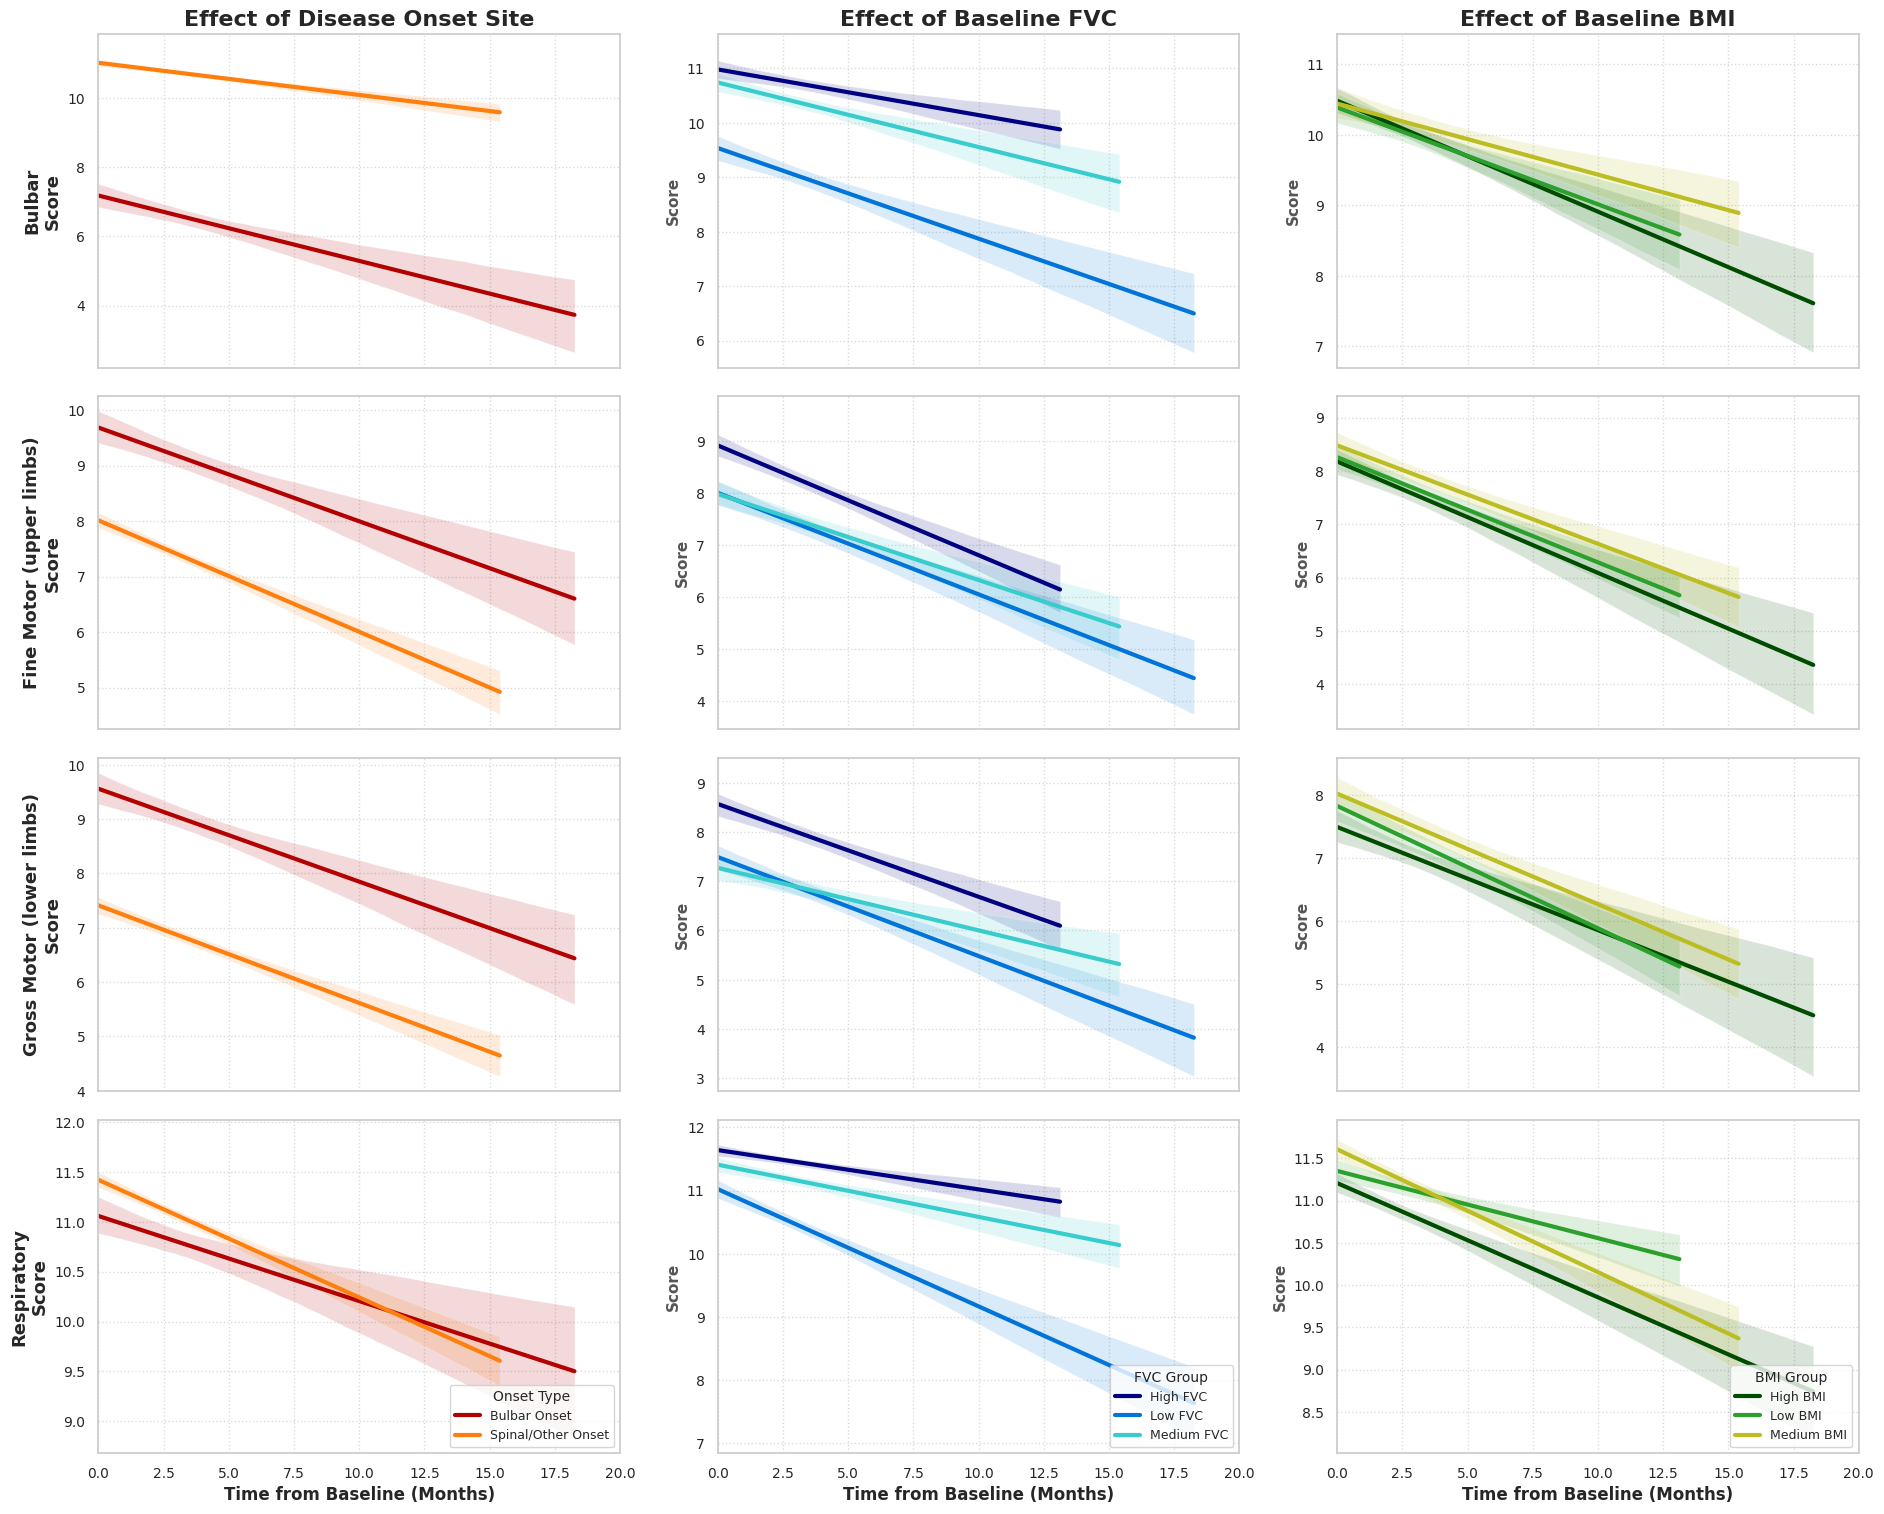

In [9]:
# ==========================================
# 8. EMPIRICAL MOTIVATION: COMPLETELY INDEPENDENT Y-AXES
# ==========================================

print("\nGenerating Empirical Motivation Plots (Independent Y-Axes)...")

df_mot = df.copy()

# Convert time from Days to Months for intuitive X-axis scaling
df_mot['Time_Months'] = df_mot['ALSFRS_Delta'] / 30.4
df_mot = df_mot[df_mot['Time_Months'] <= 20]

# 1. Stratify Continuous Covariates
df_mot['FVC_Group'] = pd.qcut(df_mot['FVC_Base'], q=3, labels=['Low FVC', 'Medium FVC', 'High FVC'])
df_mot['BMI_Group'] = pd.qcut(df_mot['BMI_Base'], q=3, labels=['Low BMI', 'Medium BMI', 'High BMI'])
df_mot['Onset_Type'] = df_mot['Bulbar_Onset'].map({1.0: 'Bulbar Onset', 0.0: 'Spinal/Other Onset'})

# 1.5 Calculate the aggregate Domain Scores
df_mot['Bulbar'] = df_mot[['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing']].sum(axis=1)
df_mot['Fine_Motor'] = df_mot[['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene']].sum(axis=1)
df_mot['Gross_Motor'] = df_mot[['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs']].sum(axis=1)
df_mot['Respiratory'] = df_mot[['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']].sum(axis=1)

domain_targets = {
    'Bulbar': 'Bulbar',
    'Fine_Motor': 'Fine Motor (upper limbs)',
    'Gross_Motor': 'Gross Motor (lower limbs)',
    'Respiratory': 'Respiratory'
}

covariate_configs = [
    {'col': 'Onset_Type', 'title': 'Effect of Disease Onset Site', 'palette': ['#b30000', '#ff7f0e']},
    {'col': 'FVC_Group', 'title': 'Effect of Baseline FVC', 'palette': ['#000080', '#0074D9', '#39CCCC']},
    {'col': 'BMI_Group', 'title': 'Effect of Baseline BMI', 'palette': ['#004d00', '#2ca02c', '#bcbd22']}
]

# 2. Setup the 4x3 Visualization Grid
# CRITICAL FIX: sharey=False completely decouples the Y-axes so every plot auto-scales perfectly
fig_cov, axes_cov = plt.subplots(4, 3, figsize=(19, 16), sharex=True, sharey=False)

for row_idx, (dom_col, dom_name) in enumerate(domain_targets.items()):
    for col_idx, config in enumerate(covariate_configs):
        
        ax = axes_cov[row_idx, col_idx]
        group_col = config['col']
        groups = df_mot[group_col].dropna().unique()
        
        if isinstance(config['palette'], list):
            colors = config['palette']
        else:
            colors = sns.color_palette(config['palette'], n_colors=len(groups))
            
        for idx, group_val in enumerate(sorted(groups)):
            subset = df_mot[df_mot[group_col] == group_val]
            
            sns.regplot(
                x='Time_Months', 
                y=dom_col, 
                data=subset, 
                ax=ax, 
                scatter=False, 
                color=colors[idx],
                label=str(group_val),
                line_kws={'linewidth': 3}
            )
            
        # --- Formatting ---
        if row_idx == 0:
            ax.set_title(config['title'], fontweight='bold', fontsize=16)
            
        # NEW Y-AXIS LOGIC: Every column gets a Y-label because the scales are independent
        if col_idx == 0:
            ax.set_ylabel(f"{dom_name}\nScore", fontweight='bold', fontsize=13)
        else:
            # Add a subtler label to columns 2 and 3 so the reader knows what the axis represents
            ax.set_ylabel("Score", fontweight='bold', fontsize=11, color='#555555')
            
        if row_idx == 3:
            ax.set_xlabel("Time from Baseline (Months)", fontweight='bold', fontsize=12)
            ax.legend(title=group_col.replace('_', ' '), loc='lower right')
        else:
            ax.set_xlabel("")
            
        ax.set_xlim(0, 20)
        ax.grid(True, linestyle=':', alpha=0.7)
        
        # Explicitly ensure tick labels are visible for every subplot
        ax.tick_params(axis='y', labelleft=True)

plt.tight_layout()
plt.subplots_adjust(top=0.93) 
save_multiformat("Fig_M_Empirical_Domain_Covariates_IndepY")
print("Generated 'Fig_M_Empirical_Domain_Covariates_IndepY' successfully.")


Generating Comprehensive Longitudinal Validation Plot...


Generated 'Fig_S_Combined_Longitudinal_Overview' successfully.


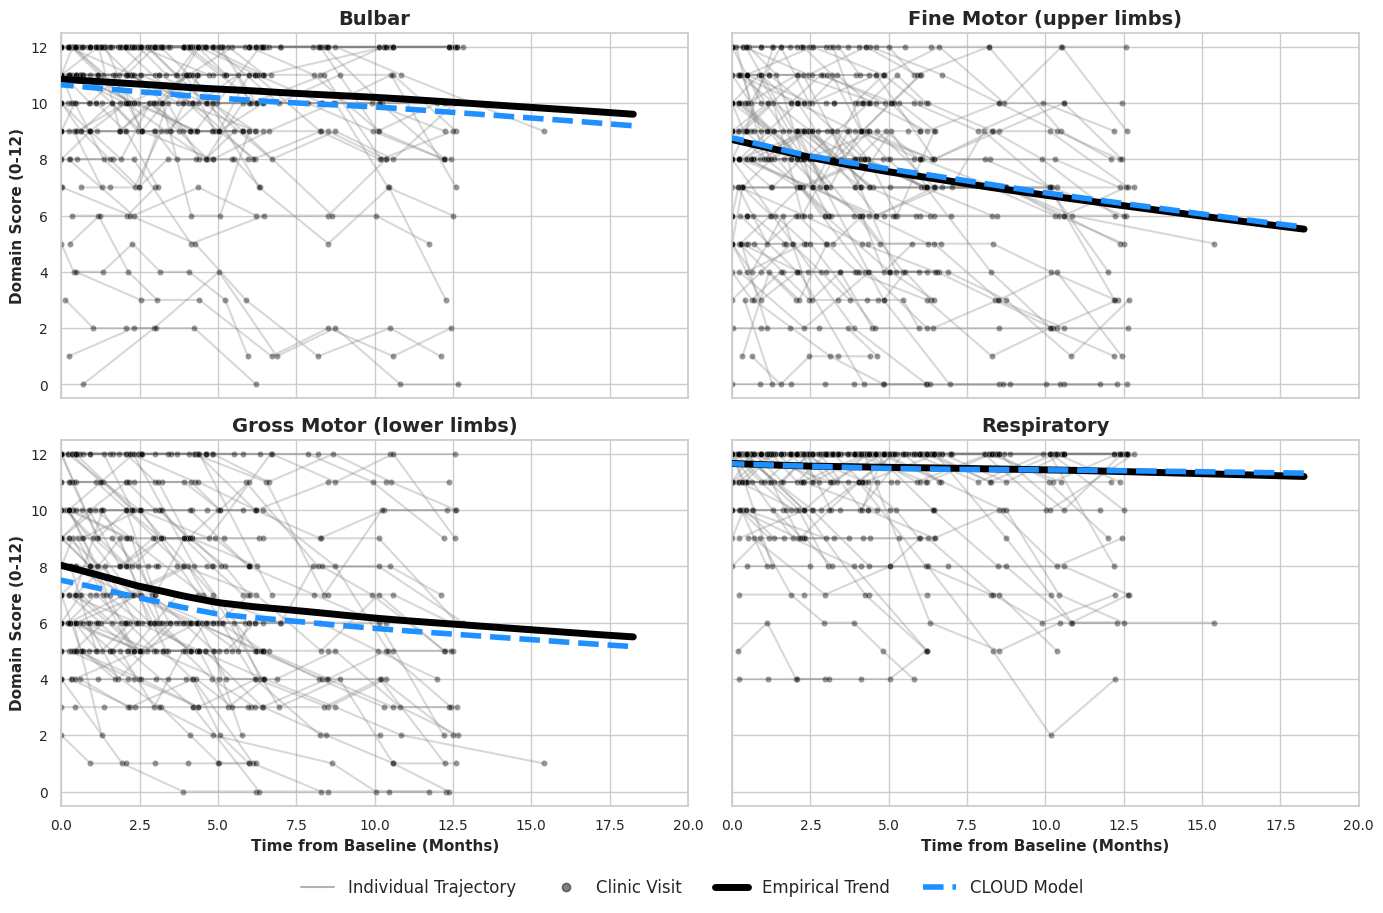

In [10]:
# ==========================================
# 12. COMPREHENSIVE LONGITUDINAL VALIDATION (WITH MASTER LEGEND)
# ==========================================
print("\nGenerating Comprehensive Longitudinal Validation Plot...")

# 1. Prep the time variable and mask for the 20-month window
time_months = df['ALSFRS_Delta'].values / 30.4
valid_idx = time_months <= 20

# 2. Sample 100 patients for the "Spaghetti" background
np.random.seed(42)
sample_subjects = np.random.choice(df.loc[valid_idx, 'subject_id'].unique(), size=100, replace=False)

# 2x2 layout with optimized height (14, 10)
fig_combo, axes_combo = plt.subplots(2, 2, figsize=(14, 10), sharey=True, sharex=True) 

# FINAL TUNE 1: Lower the title to 93.1% (almost touching the subplot boundary)
# fig_combo.suptitle("Comprehensive Longitudinal Validation: Individual Chaos vs. Model Trajectory", fontweight='bold', fontsize=18, y=0.931)

# Flatten the 2x2 axes grid to a 1D array of 4 elements for easy indexing
axes_flat = axes_combo.flatten()

domain_labels = ['Bulbar', 'Fine Motor (upper limbs)', 'Gross Motor (lower limbs)', 'Respiratory']

for d, items in domain_idx_full.items():
    ax = axes_flat[d]
    dom_name = domain_labels[d]
    
    # Extract Actual and Predicted Scores for ALL patients
    actual_dom_all = actual_sc[:, items].sum(axis=1)
    pred_dom_all = exp_sc[:, items].sum(axis=1)
    
    # Create a dataframe for the LOESS curves (ALL data)
    df_all = pd.DataFrame({
        'subject_id': df['subject_id'],
        'Time_Months': time_months,
        'Actual_Score': actual_dom_all,
        'Predicted_Score': pred_dom_all
    })
    df_all_valid = df_all[valid_idx]
    
    # Create a sub-dataframe for the Spaghetti plots (SAMPLED data)
    df_sample = df_all_valid[df_all_valid['subject_id'].isin(sample_subjects)]
    
    # --- LAYER 1: The Raw Individual Lines (Spaghetti) ---
    sns.lineplot(
        data=df_sample, x='Time_Months', y='Actual_Score', units='subject_id', estimator=None,
        color='gray', alpha=0.3, linewidth=1.5, ax=ax, zorder=1
    )
    
    # --- LAYER 2: The Raw Clinic Visits (Scatter) ---
    sns.scatterplot(
        data=df_sample, x='Time_Months', y='Actual_Score',
        color='black', alpha=0.4, s=20, ax=ax, zorder=2
    )
    
    # --- LAYER 3: The True Population Mean (Solid Black Line) ---
    sns.regplot(
        data=df_all_valid, x='Time_Months', y='Actual_Score', scatter=False, lowess=True, 
        color='black', line_kws={'linewidth': 5, 'zorder': 4}, ax=ax
    )
    
    # --- LAYER 4: The Model's Predicted Mean (Dashed Blue Line) ---
    sns.regplot(
        data=df_all_valid, x='Time_Months', y='Predicted_Score', scatter=False, lowess=True, 
        color='dodgerblue', line_kws={'linewidth': 4, 'linestyle': '--', 'zorder': 5}, ax=ax
    )

    ax.set_title(dom_name, fontweight='bold', fontsize=14)
    ax.set_xlim(0, 20)
    ax.set_ylim(-0.5, 12.5)

    # Label X-axis only on the bottom row (indices 2 and 3)
    if d >= 2:
        ax.set_xlabel("Time from Baseline (Months)", fontweight='bold')
    else:
        ax.set_xlabel("")

    # Label Y-axis only on the left column (indices 0 and 2)
    if d % 2 == 0:
        ax.set_ylabel("Domain Score (0-12)", fontweight='bold')
    else:
        ax.set_ylabel("")

# --- BUILD THE MASTER LEGEND ---
legend_elements = [
    mlines.Line2D([], [], color='gray', alpha=0.6, linewidth=1.5, label='Individual Trajectory'),
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', alpha=0.5, markersize=6, label='Clinic Visit'),
    mlines.Line2D([], [], color='black', linewidth=5, label='Empirical Trend'),
    mlines.Line2D([], [], color='dodgerblue', linewidth=4, linestyle='--', label='CLOUD Model')
]

# PUBLICATION FORMATTING: Single horizontal line, no box, placed at the very bottom.
fig_combo.legend(
    handles=legend_elements, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.01), # Centered, slightly above the bottom edge of the figure canvas
    ncol=4,                     # Spreads the 4 items into a single row
    fontsize=12, 
    frameon=False               # Removes the bounding box/shadow (crucial for publication style)
)

# FINAL TUNE 2: Keep the top bound of the subplots at 93% 
# Boundaries defined as: rect=[left, bottom, right, top]
plt.tight_layout(rect=[0, 0.05, 1, 0.93]) 

save_multiformat("Fig_S_Combined_Longitudinal_Overview")
print("Generated 'Fig_S_Combined_Longitudinal_Overview' successfully.")

 -> No direct domain-level covariate rows found for Sex_Female. Skipping forest plot.
 -> No direct domain-level covariate rows found for Treatment_Active. Skipping forest plot.
 -> No direct domain-level covariate rows found for Age_Base. Skipping forest plot.
 -> Generated domain-level forest plot for Bulbar_Onset.
 -> Generated domain-level forest plot for FVC_Base.
 -> Generated domain-level forest plot for BMI_Base.


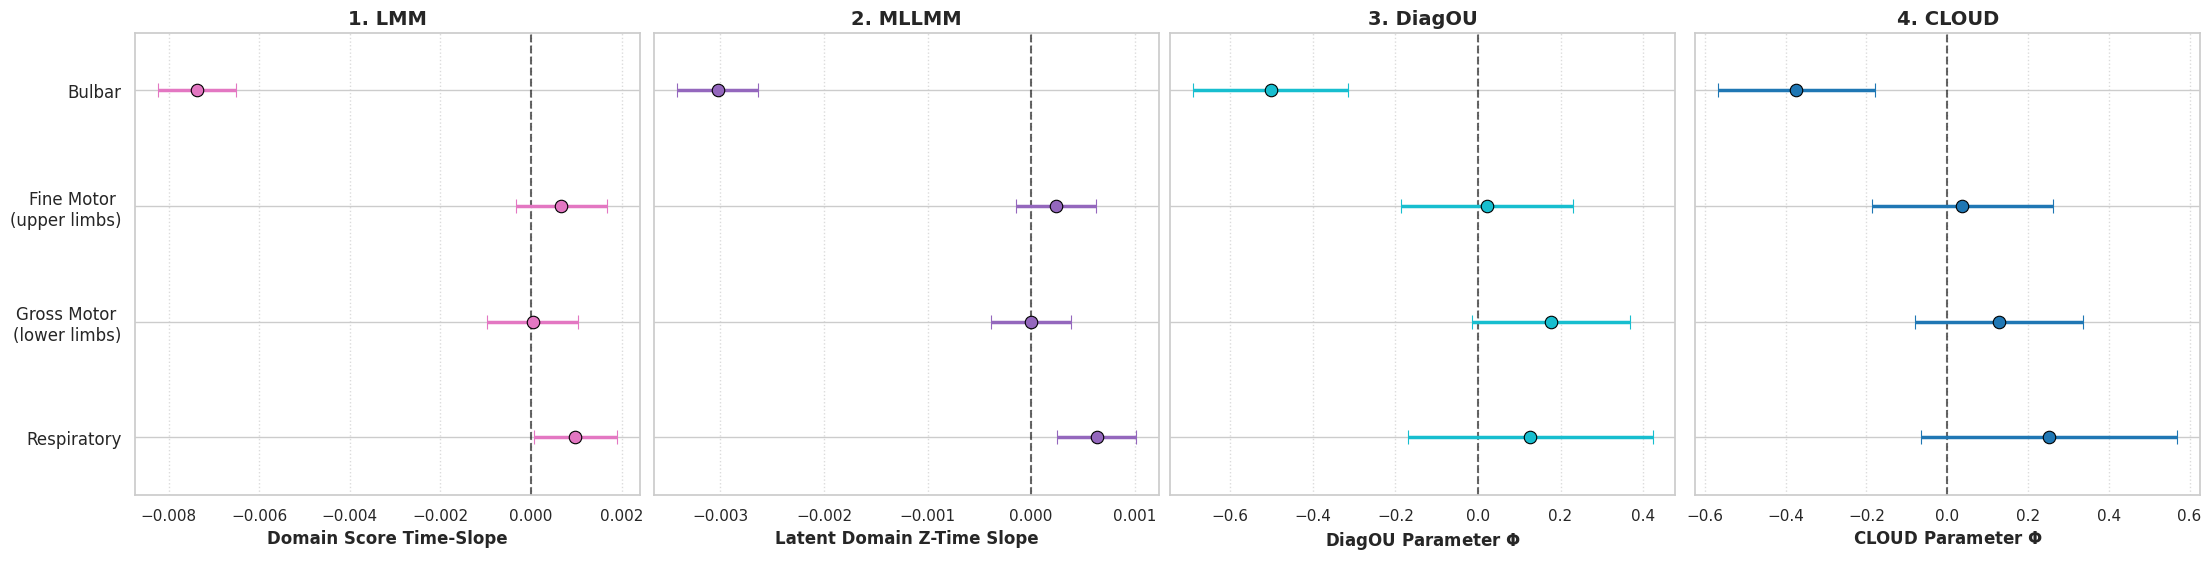

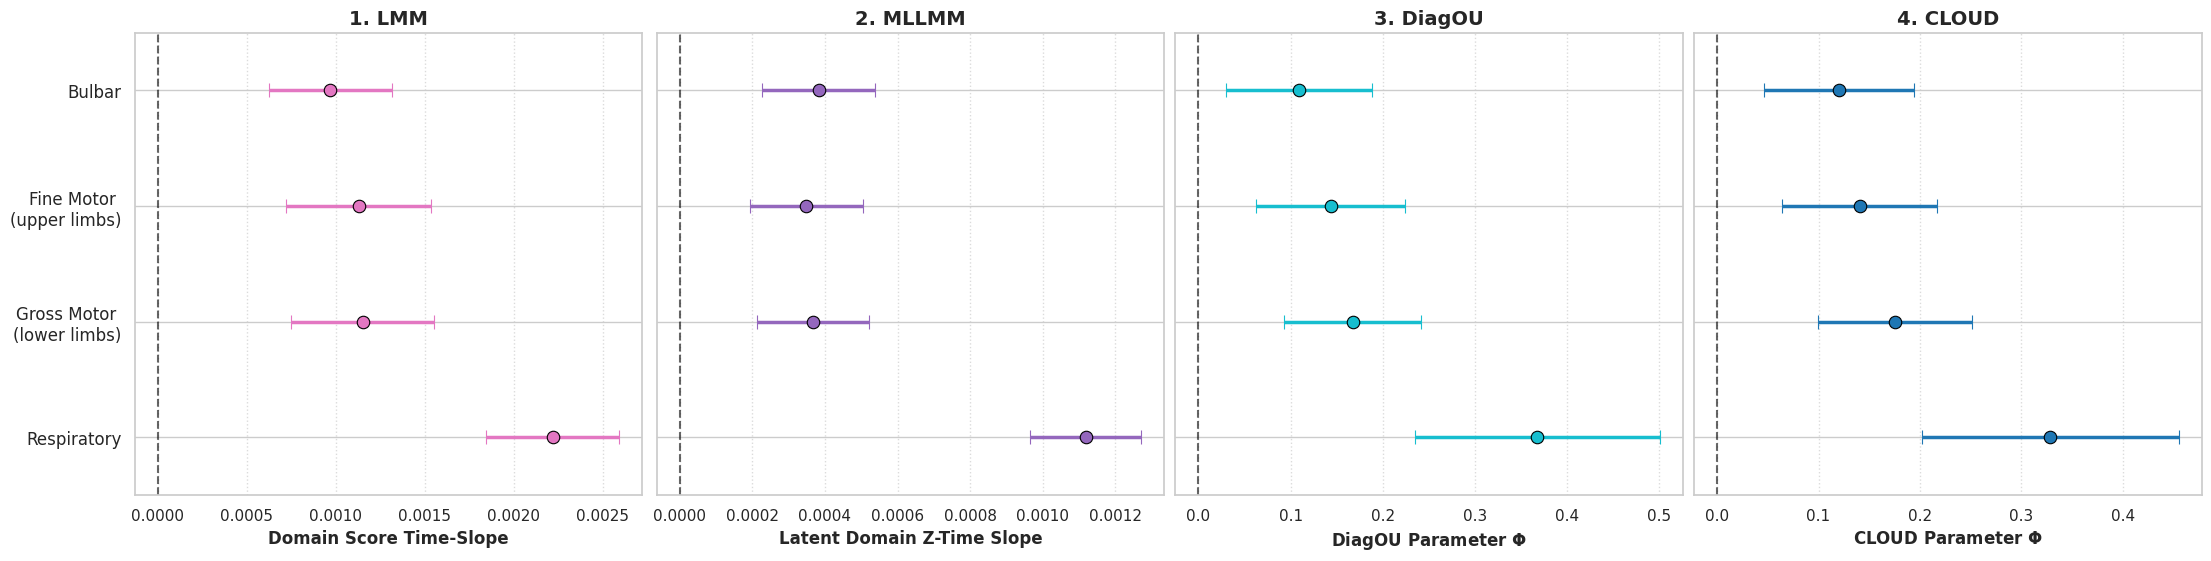

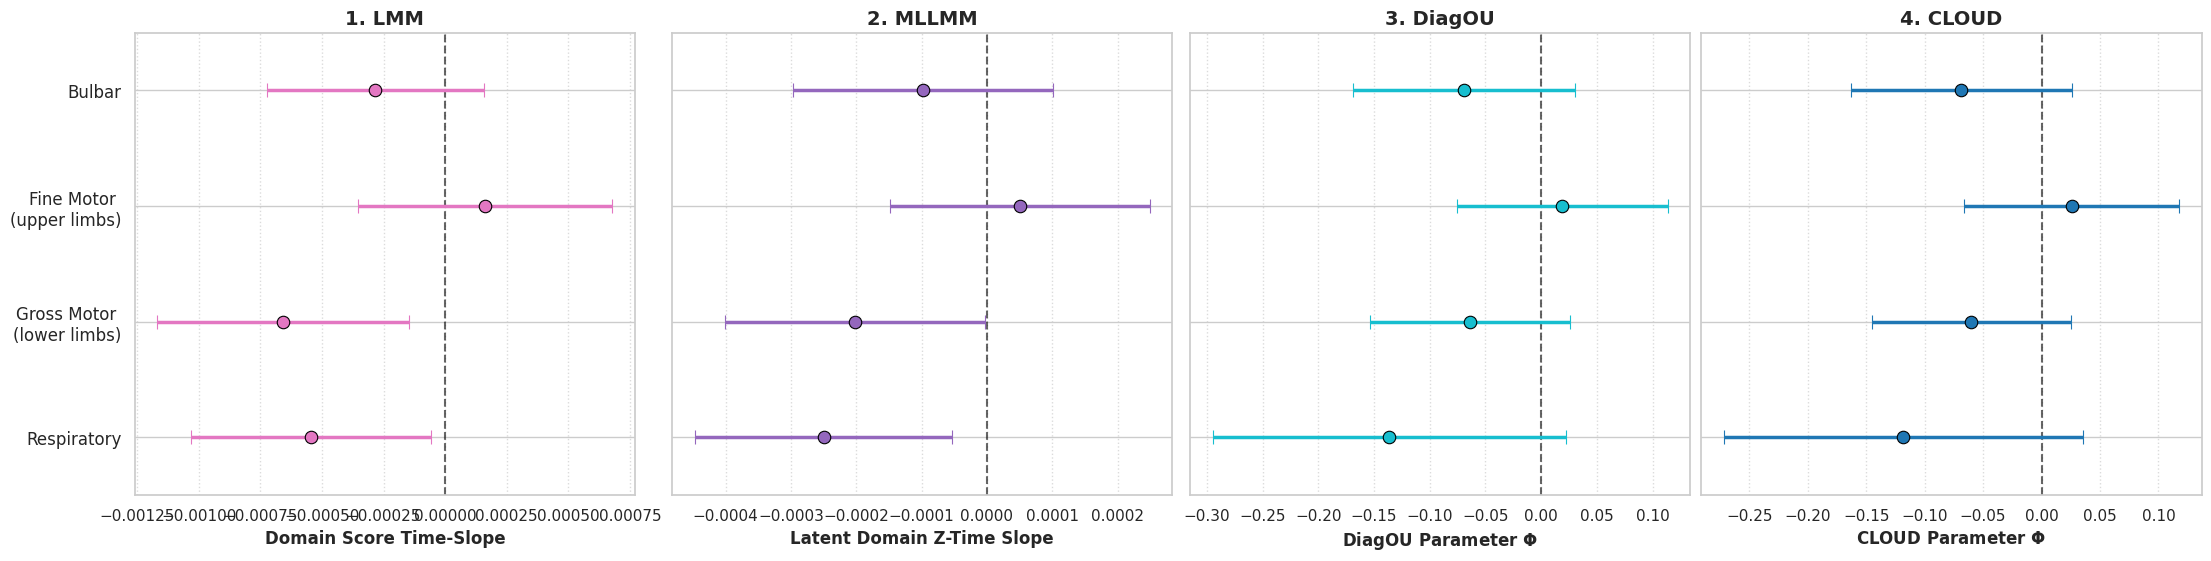

In [15]:
# ==========================================
# Generate one domain-level forest plot per covariate (1x4 Layout)
# ==========================================

if not df_domain_covs_plot.empty:
    sns.set_theme(
        style="whitegrid",
        rc={
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "savefig.facecolor": "white"
        }
    )

    domain_labels = [domain_label_map[d] for d in domain_order]

    # Put Bulbar visually at the top without calling invert_yaxis repeatedly.
    domain_to_y = {
        label: len(domain_labels) - 1 - i
        for i, label in enumerate(domain_labels)
    }

    ytick_positions = [domain_to_y[label] for label in domain_labels]
    ytick_labels = domain_labels

    for cov in all_covariates:
        subset = df_domain_covs_plot[
            df_domain_covs_plot['Covariate'].astype(str) == cov
        ].copy()

        if subset.empty:
            print(f" -> No direct domain-level covariate rows found for {cov}. Skipping forest plot.")
            continue

        subset['Model_Str'] = subset['Model'].astype(str)
        subset['Domain_Label_Str'] = subset['Domain_Label'].astype(str)
        subset['Est'] = pd.to_numeric(subset['Est'], errors='coerce')
        subset['SE'] = pd.to_numeric(subset['SE'], errors='coerce')

        subset = subset[
            subset['Model_Str'].isin(forest_model_order)
        ].copy()

        # UPDATED: 1 row, 4 columns. 
        # figsize adjusted to (22, 5.5) for a wide, publication-ready horizontal spread
        fig, axes = plt.subplots(
            1, 4,
            figsize=(22, 5.5),
            sharey=True,
            constrained_layout=True
        )

        axes_flat = axes.flatten()

        for i, model in enumerate(forest_model_order):
            ax = axes_flat[i]

            mod_data = subset[subset['Model_Str'] == model].copy()
            mod_data['y_pos'] = mod_data['Domain_Label_Str'].map(domain_to_y)

            mod_data = mod_data.dropna(
                subset=['y_pos', 'Est']
            ).copy()

            mod_data['y_pos'] = mod_data['y_pos'].astype(float)
            mod_data['CI_Margin'] = 1.96 * mod_data['SE'].abs()

            mod_data = mod_data.sort_values('y_pos')

            # Zero reference line
            ax.axvline(
                x=0,
                color='black',
                linestyle='--',
                linewidth=1.5,
                alpha=0.6,
                zorder=1
            )

            if not mod_data.empty:
                c_val = model_colors.get(model, '#333333')

                # Plot rows with valid SE using 95% CI
                with_ci = mod_data[
                    mod_data['CI_Margin'].notna()
                    & np.isfinite(mod_data['CI_Margin'])
                ]

                if not with_ci.empty:
                    ax.errorbar(
                        x=with_ci['Est'].values,
                        y=with_ci['y_pos'].values,
                        xerr=with_ci['CI_Margin'].values,
                        fmt='o',
                        color=c_val,
                        ecolor=c_val,
                        elinewidth=2.5,
                        capsize=5,
                        capthick=2,
                        markersize=9,
                        markeredgecolor='black',
                        markeredgewidth=0.8,
                        zorder=3
                    )

                # Plot rows without valid SE as point-only estimates
                no_ci = mod_data[
                    mod_data['CI_Margin'].isna()
                    | ~np.isfinite(mod_data['CI_Margin'])
                ]

                if not no_ci.empty:
                    ax.scatter(
                        no_ci['Est'].values,
                        no_ci['y_pos'].values,
                        s=90,
                        color=c_val,
                        edgecolor='black',
                        linewidth=0.8,
                        zorder=3
                    )

            else:
                ax.text(
                    0.5,
                    0.5,
                    "No direct\ndomain-level\nestimate",
                    ha='center',
                    va='center',
                    transform=ax.transAxes,
                    fontsize=12,
                    color='gray',
                    fontweight='bold'
                )

            ax.set_title(model, fontweight='bold', fontsize=14)
            ax.set_xlabel(get_forest_xlabel(model, cov), fontweight='bold', fontsize=12)

            ax.grid(
                True,
                axis='x',
                linestyle=':',
                alpha=0.7,
                zorder=0
            )

            ax.set_axisbelow(True)

            ax.set_yticks(ytick_positions)

            # UPDATED: Only display Y-axis labels on the very first subplot (far left)
            if i == 0:
                ax.set_yticklabels(ytick_labels, fontsize=12)
            else:
                ax.tick_params(axis='y', labelleft=False)

            ax.set_ylim(-0.5, len(domain_labels) - 0.5)

        save_multiformat(f"Fig_D_Domain_Forest_{cov}")
        # plt.close(fig)

        print(f" -> Generated domain-level forest plot for {cov}.")

In [12]:
def extract_and_save_parameters(df, output_filename='filtered_mcmc_parameters.csv'):
    """
    Filters an MCMC DataFrame for specific parameters, groups matrix entries 
    together, saves the result to a CSV, and returns the filtered DataFrame.
    """
    targets = [
        'lambda', 'alpha_dyn', 'alpha_0', 'theta', 
        'beta', 'Gamma', 'sigma_bk', 'rho'
    ]
    
    # Create a working copy to avoid modifying the original dataframe
    working_df = df.copy()
    
    # 1. Extract the base parameter name (e.g., 'theta[1,2]' becomes 'theta')
    working_df['base_param'] = working_df['Parameter'].str.split('[').str[0]
    
    # 2. Filter the DataFrame to only include our targets
    sub_df = working_df[working_df['base_param'].isin(targets)].copy()
    
    # 3. Sort the rows to group parameters together. 
    # Sorting by 'base_param' chunks them by parameter family.
    # Sorting by 'Parameter' orders the bracketed indices.
    # Sorting by 'Run_ID' keeps iterations of the same parameter sequential.
    sub_df = sub_df.sort_values(by=['base_param', 'Parameter', 'Run_ID'])
    sub_df["Std"] = sub_df["MCSE"] * np.sqrt(sub_df["ESS"])
    
    # 4. Drop the temporary 'base_param' column to keep your original schema clean
    sub_df = sub_df.drop(columns=['base_param'])
    
    # 5. Save the final DataFrame to a CSV
    sub_df.to_csv(output_filename, index=False)
    
    return sub_df


Generated 'Fig_I_4D_Interaction_ForestPlot.png' successfully.


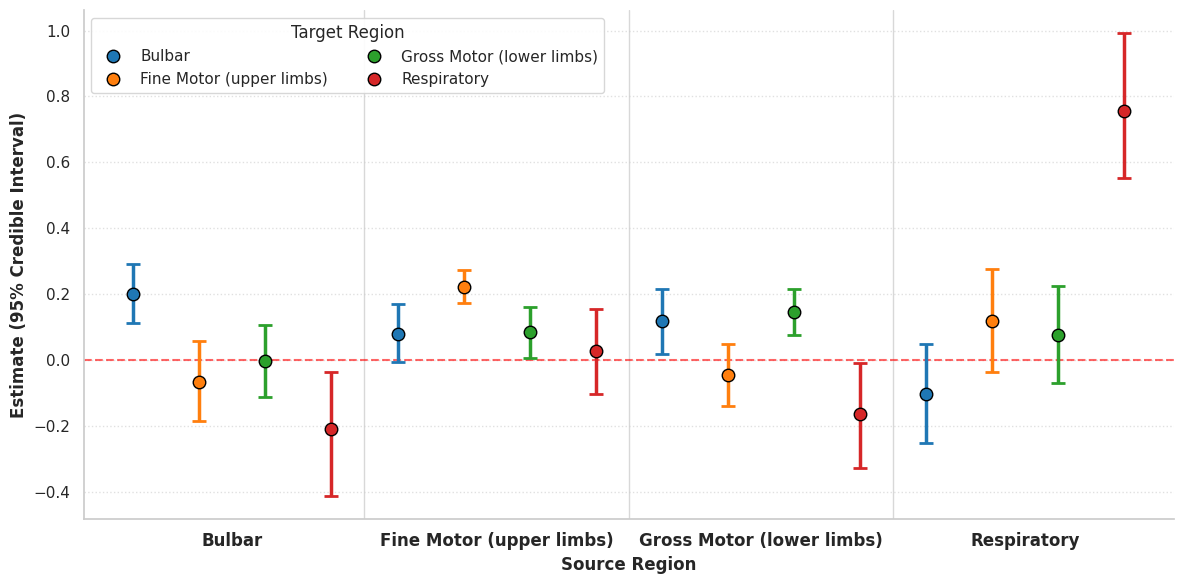

In [13]:
# ==========================================
# 4D INTERACTION FOREST PLOT (Point + 95% CI)
# ==========================================

# Load and filter data
cloud_df = pd.read_csv("../new_results/results_S1_dahlou_ncp_full_run1.csv")

# Ensure extract_and_save_parameters is defined in your script
try:
    filtered_df = extract_and_save_parameters(cloud_df)
except NameError:
    filtered_df = cloud_df # Fallback if running as isolated snippet

gamma_df = filtered_df[filtered_df["Parameter"].str.contains("Gamma")].copy()
cloud_df = gamma_df.copy()

def parse_param(param):
    match = re.match(r"Gamma\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

cloud_df[["i", "j"]] = cloud_df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# ---- 1. EXPLICIT DATA MAPPING ----
# We map the raw Stan indices strictly to their original names
stan_domain_map = {
    0: "Bulbar",
    1: "Fine Motor (upper limbs)",
    2: "Gross Motor (lower limbs)",
    3: "Respiratory"
}
cloud_df["target_domain"] = cloud_df["i"].map(stan_domain_map)
cloud_df["source_domain"] = cloud_df["j"].map(stan_domain_map)

# ---- 2. CUSTOM X-AXIS SORTING ----
# Define the exact physical order you want on the X-axis
x_axis_order = ["Bulbar", "Fine Motor (upper limbs)", "Gross Motor (lower limbs)", "Respiratory"]

# Convert 'source_domain' to an ordered categorical type
cloud_df["source_domain"] = pd.Categorical(
    cloud_df["source_domain"], 
    categories=x_axis_order, 
    ordered=True
)

# Sort by the new custom Source order, then by Standard Target index to keep dots grouped neatly
cloud_df = cloud_df.sort_values(["source_domain", "i"]).reset_index(drop=True)

# ---- 3. EXPLICIT COLOR MAPPING ----
# Map colors directly to names so they NEVER misalign
color_map = {
    "Bulbar": "#1f77b4",       # Blue
    "Fine Motor (upper limbs)": "#ff7f0e",     # Orange
    "Gross Motor (lower limbs)": "#2ca02c",       # Green
    "Respiratory": "#d62728"   # Red
}
# Apply colors based on the target domain column
colors = cloud_df["target_domain"].map(color_map)

# ---- Vertical Forest Plot Setup ----
fig, ax = plt.subplots(figsize=(12, 6))  

# Reference line at 0 (No interaction effect)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.6, zorder=1)

# Draw individual error bars (Forest Plot)
for idx, row in cloud_df.iterrows():
    est = row['Estimate']
    lower = row['2.5%']
    upper = row['97.5%']
    
    c = colors.iloc[idx]
    
    yerr = [[est - lower], [upper - est]]
    
    ax.errorbar(
        x=idx,
        y=est,
        yerr=yerr,
        fmt='o',                   
        color=c,
        ecolor=c,                  
        elinewidth=2.5,            
        capsize=5,                 
        capthick=2,
        markersize=9,              
        markeredgecolor='black',   
        zorder=3
    )

# X-Axis Setup (Centers of the 4 groups)
ax.set_xticks([1.5, 5.5, 9.5, 13.5])
# Use the custom order list we defined earlier for the tick labels
ax.set_xticklabels(x_axis_order, fontsize=12, fontweight='bold')
ax.set_xlabel("Source Region", fontsize=12, fontweight='bold')

# Y-Axis Setup
ax.set_ylabel("Estimate (95% Credible Interval)", fontsize=12, fontweight='bold')
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
# ax.set_ylim(y_min, y_max + (y_range * 0.25))

# ---- CLEANUP & GRID FIXES ----
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.grid(False) 
ax.yaxis.grid(True, linestyle=':', alpha=0.6, zorder=0)

# Solid group separators between the domains
for k in range(1, 4):
    ax.axvline(k*4 - 0.5, color="gray", linestyle="-", linewidth=1.0, alpha=0.3, zorder=0)

# ---- Legend Code ----
# Order the legend logically (Standard anatomical order)
legend_order = ["Bulbar", "Fine Motor (upper limbs)", "Gross Motor (lower limbs)", "Respiratory"]
handles = [
    plt.Line2D([0], [0], marker='o', markersize=9, markeredgecolor='black', 
               linestyle='', color=color_map[domain], label=domain)
    for domain in legend_order
]

ax.legend(
    handles=handles, 
    title="Target Region", 
    loc='upper left',           
    frameon=True,               
    facecolor='white',          
    framealpha=0.9,             
    edgecolor='lightgray',      
    ncol=2                      
)

plt.tight_layout()

# Save outputs
try:
    save_multiformat("Fig_I_4D_Interaction_ForestPlot")
except NameError:
    plt.savefig("Fig_I_4D_Interaction_ForestPlot.png", dpi=300, bbox_inches='tight')

print("Generated 'Fig_I_4D_Interaction_ForestPlot.png' successfully.")

Generated 'Fig_I_4D_Covariate_ForestPlot_Vertical_Fixed.png' successfully.


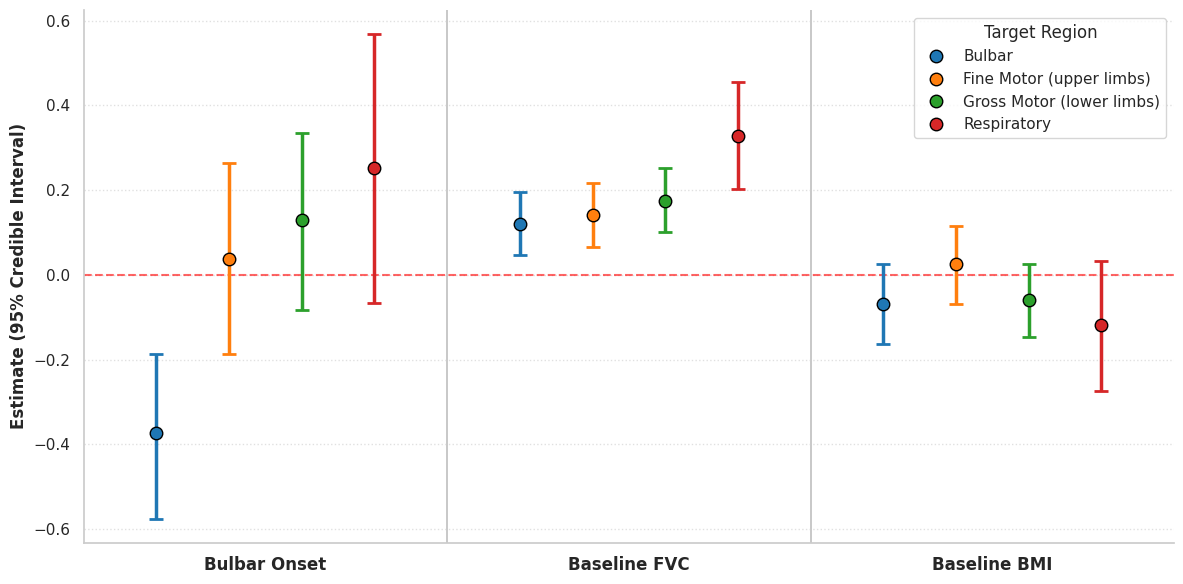

In [14]:
# ==========================================
# COVARIATE FOREST PLOT (Point + 95% CI) - Vertical (Fixed)
# ==========================================
# Assuming filtered_df is defined in your broader script
try:
    cloud_alpha_df = filtered_df[filtered_df["Parameter"].str.contains("alpha_dyn")].copy()
except NameError:
    pass 

cloud_a_df = cloud_alpha_df.copy()

i_labels = ["Bulbar", "Fine Motor (upper limbs)", "Gross Motor (lower limbs)", "Respiratory"]
j_labels = ["Bulbar Onset", "Baseline FVC", "Baseline BMI"]

def parse_param(param):
    # More robust regex to handle potential spaces (e.g., [4, 1] instead of [4,1])
    match = re.search(r"\[\s*(\d+)\s*,\s*(\d+)\s*\]", str(param))
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

cloud_a_df[["i", "j"]] = cloud_a_df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# Fallback: if parameter strings don't match the regex, assume standard sequential order 
# (prevents points from mysteriously disappearing)
if cloud_a_df["i"].isnull().all():
    n = len(cloud_a_df)
    cloud_a_df["j"] = np.repeat(range(len(j_labels)), len(i_labels))[:n]
    cloud_a_df["i"] = np.tile(range(len(i_labels)), len(j_labels))[:n]

# Sort sequentially by covariate group then region
cloud_a_df = cloud_a_df.sort_values(["j", "i"]).reset_index(drop=True)

color_map = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c", 3: "#d62728"}

fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal reference line at 0
ax.axhline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.6, zorder=1)

# ---- Dynamic Positioning Logic ----
x_positions = []
group_centers = []
group_labels = []
v_lines = []
current_x = 0

# Group by Covariate and add physical gaps between clusters dynamically
for j_val, group in cloud_a_df.groupby("j", sort=False):
    start_x = current_x
    for _ in range(len(group)):
        x_positions.append(current_x)
        current_x += 1
    
    # Calculate perfect center of the current cluster for the label
    center = (start_x + current_x - 1) / 2
    group_centers.append(center)
    
    j_int = int(j_val) if pd.notnull(j_val) else 0
    label = j_labels[j_int] if j_int < len(j_labels) else f"Covariate {j_int}"
    group_labels.append(label)
    
    # Mark the gap for the vertical line
    v_lines.append(current_x)
    current_x += 1 # Add empty space between groups

v_lines = v_lines[:-1] # Drop the final trailing vertical line
cloud_a_df["x_pos"] = x_positions

# ---- Plotting ----
for idx, row in cloud_a_df.iterrows():
    est = row['Estimate']
    lower = row['2.5%']
    upper = row['97.5%']
    x_val = row['x_pos']
    
    # .get() prevents errors if an unknown index slips through
    c = color_map.get(row['i'], "#333333") 
    
    yerr = [[est - lower], [upper - est]]
    
    ax.errorbar(
        x=x_val, y=est, yerr=yerr, fmt='o',                   
        color=c, ecolor=c, elinewidth=2.5, capsize=5,                 
        capthick=2, markersize=9, markeredgecolor='black', zorder=3
    )

# Apply axes labels and limits
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, fontsize=12, fontweight='bold')
ax.set_ylabel("Estimate (95% Credible Interval)", fontsize=12, fontweight='bold')
ax.set_xlim(-1, current_x - 1) # Ensure dots don't hug the left/right borders

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Grid lines: Keep Y dotted lines, completely disable X dotted lines to avoid confusion
ax.grid(True, axis='y', linestyle=':', alpha=0.6, zorder=0)
ax.grid(False, axis='x')

# Draw the solid vertical separators exactly in the gaps
for v in v_lines:
    ax.axvline(v, color="gray", linestyle="-", linewidth=1.2, alpha=0.5, zorder=0)

# Legend (Top right, inside axis)
handles = [
    plt.Line2D([0], [0], marker='o', markersize=9, markeredgecolor='black', 
               linestyle='', color=color_map[i], label=i_labels[i])
    for i in range(len(i_labels))
]
ax.legend(handles=handles, title="Target Region", frameon=True, loc="upper right")

plt.tight_layout()

# Save outputs
try:
    save_multiformat("Fig_I_4D_Covariate_ForestPlot_Vertical_Fixed")
except NameError:
    plt.savefig("Fig_I_4D_Covariate_ForestPlot_Vertical_Fixed.png", dpi=300, bbox_inches='tight')

print("Generated 'Fig_I_4D_Covariate_ForestPlot_Vertical_Fixed.png' successfully.")